# <p style="background-color:#2b1055; font-family:Trebuchet MS, sans-serif; color:#ffffff; font-size:150%; text-align:center; border-radius:10px;">Capstone Project | Predicting Movie Success</p>

<div style="border-radius:8px; padding: 15px; background-color:#e8e4f0; color:#000000; font-size:120%; text-align:left">

<h3 align="left"><font color="#d4a017">Problem:</font></h3>

Our client, a major film studio, aims to enhance their understanding of factors influencing movie success and improve prediction models for IMDB ratings. The dataset contains **28 variables for 5,043 movies**, spanning across 100 years in 66 countries. There are 2,399 unique director names and thousands of actors/actresses. The goal is to leverage advanced data analysis techniques and machine learning to predict whether a movie will be a **Hit**, **Average**, or **Flop** based on IMDB scores and other movie attributes.
</div>

<div style="border-radius:8px; padding: 15px; background-color:#e8e4f0; color:#000000; font-size:115%; text-align:left">

<h3 align="left"><font color="#d4a017">Objectives:</font></h3>

* __Explore the Dataset__: Understand feature distributions, relationships, and data quality.
* __Conduct Comprehensive EDA__: Univariate and bivariate analysis with visualizations.
* __Preprocessing__:
  - Handle missing values
  - Treat outliers
  - Encode categorical variables
  - Address multicollinearity
  - Scale features
* __Feature Engineering__: Categorize IMDB scores into Hit/Average/Flop and analyze feature importance.
* __Model Building__: Train and evaluate Logistic Regression, Random Forest, and an optimized best-model search.
* __Evaluate and Compare Model Performance__: Use confusion matrices, classification reports, and accuracy comparisons.
</div>

<a id="contents_table"></a>
<div style="border-radius:8px; padding: 15px; background-color:#e8e4f0; color:#000000; font-size:115%; text-align:left">

<h3 align="left"><font color="#d4a017">Table of Contents:</font></h3>

* [Step 1 | Import Libraries](#step1)
* [Step 2 | Load Dataset](#step2)
* [Step 3 | Dataset Overview](#step3)
* [Step 4 | Exploratory Data Analysis (EDA)](#step4)
    - [Step 4.1 | Univariate Analysis](#step4_1)
    - [Step 4.2 | Bivariate Analysis (Features vs Target)](#step4_2)
    - [Step 4.3 | Correlation Heatmap](#step4_3)
* [Step 5 | Data Preprocessing](#step5)
    - [Step 5.1 | Missing Value Treatment](#step5_1)
    - [Step 5.2 | Target Variable Creation](#step5_2)
    - [Step 5.3 | Outlier Treatment](#step5_3)
    - [Step 5.4 | Multicollinearity Treatment](#step5_4)
    - [Step 5.5 | Encoding & Scaling](#step5_5)
* [Step 6 | Model Building & Evaluation](#step6)
    - [Step 6.1 | Logistic Regression](#step6_1)
    - [Step 6.2 | Random Forest Classifier](#step6_2)
    - [Step 6.3 | Optimized Model Search (mesh_utils)](#step6_3)
* [Step 7 | Model Comparison](#step7)
* [Step 8 | Feature Importance](#step8)
* [Step 9 | Model Export](#step9)
* [Step 10 | Conclusion](#step10)
</div>

<a id="step1"></a>
# <p style="background-color:#2b1055; font-family:Trebuchet MS, sans-serif; color:#ffffff; font-size:150%; text-align:center; border-radius:10px;">Phase 1: Import Libraries</p>

[â†‘ Back to Top](#contents_table)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# Set plot aesthetics â€” presentation-friendly settings
plt.rcParams["figure.dpi"] = 150
plt.rcParams["savefig.dpi"] = 200
plt.rcParams["font.size"] = 12
plt.rcParams["axes.titlesize"] = 16
plt.rcParams["axes.labelsize"] = 13
plt.rcParams["figure.facecolor"] = "white"
sns.set_style("whitegrid")


<a id="step2"></a>
# <p style="background-color:#2b1055; font-family:Trebuchet MS, sans-serif; color:#ffffff; font-size:150%; text-align:center; border-radius:10px;">Phase 2: Load Dataset</p>

[â†‘ Back to Top](#contents_table)

In [2]:
df = pd.read_csv("movie_metadata.csv")
print(f"Dataset Shape: {df.shape}")


Dataset Shape: (5043, 28)


<a id="step3"></a>
# <p style="background-color:#2b1055; font-family:Trebuchet MS, sans-serif; color:#ffffff; font-size:150%; text-align:center; border-radius:10px;">Phase 3: Dataset Overview</p>

[â†‘ Back to Top](#contents_table)

<div style="border-radius:8px; padding: 15px; background-color:#e8e4f0; color:#000000; font-size:115%; text-align:left">
Let's examine the dataset's structure, data types, and summary statistics:
</div>

In [3]:
# Dataset basic information
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5043 entries, 0 to 5042
Data columns (total 28 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   color                      5024 non-null   object 
 1   director_name              4939 non-null   object 
 2   num_critic_for_reviews     4993 non-null   float64
 3   duration                   5028 non-null   float64
 4   director_facebook_likes    4939 non-null   float64
 5   actor_3_facebook_likes     5020 non-null   float64
 6   actor_2_name               5030 non-null   object 
 7   actor_1_facebook_likes     5036 non-null   float64
 8   gross                      4159 non-null   float64
 9   genres                     5043 non-null   object 
 10  actor_1_name               5036 non-null   object 
 11  movie_title                5043 non-null   object 
 12  num_voted_users            5043 non-null   int64  
 13  cast_total_facebook_likes  5043 non-null   int64

In [4]:
# Summary statistics for numerical features
df.describe().T


,count,mean,std,min,25%,50%,75%,max
num_critic_for_reviews,4993.0,1.401943e+02,1.216017e+02,1.00,50.00,110.00,195.00,8.130000e+02
duration,5028.0,1.072011e+02,2.519744e+01,7.00,93.00,103.00,118.00,5.110000e+02
director_facebook_likes,4939.0,6.865092e+02,2.813329e+03,0.00,7.00,49.00,194.50,2.300000e+04
actor_3_facebook_likes,5020.0,6.450098e+02,1.665042e+03,0.00,133.00,371.50,636.00,2.300000e+04
actor_1_facebook_likes,5036.0,6.560047e+03,1.502076e+04,0.00,614.00,988.00,11000.00,6.400000e+05
gross,4159.0,4.846841e+07,6.845299e+07,162.00,5340987.50,25517500.00,62309437.50,7.605058e+08
num_voted_users,5043.0,8.366816e+04,1.384853e+05,5.00,8593.50,34359.00,96309.00,1.689764e+06
cast_total_facebook_likes,5043.0,9.699064e+03,1.816380e+04,0.00,1411.00,3090.00,13756.50,6.567300e+05
facenumber_in_poster,5030.0,1.371173e+00,2.013576e+00,0.00,0.00,1.00,2.00,4.300000e+01
num_user_for_reviews,5022.0,2.727708e+02,3.779829e+02,1.00,65.00,156.00,326.00,5.060000e+03


In [5]:
# Summary statistics for categorical features
df.describe(include='object').T


,count,unique,top,freq
color,5024,2,Color,4815
director_name,4939,2398,Steven Spielberg,26
actor_2_name,5030,3032,Morgan Freeman,20
genres,5043,914,Drama,236
actor_1_name,5036,2097,Robert De Niro,49
movie_title,5043,4917,King Kong,3
actor_3_name,5020,3521,Steve Coogan,8
plot_keywords,4890,4760,based on novel,4
movie_imdb_link,5043,4919,http://www.imdb.com/title/tt0232500/?ref_=fn_t...,3
language,5029,46,English,4704


In [6]:
# Check missing values
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(1)
missing_df = pd.DataFrame({"Missing Count": missing, "Percentage (%)": missing_pct})
print("\nMissing Values Summary:")
print(missing_df[missing_df['Missing Count'] > 0])



Missing Values Summary:
                         Missing Count  Percentage (%)
color                               19             0.4
director_name                      104             2.1
num_critic_for_reviews              50             1.0
duration                            15             0.3
director_facebook_likes            104             2.1
actor_3_facebook_likes              23             0.5
actor_2_name                        13             0.3
actor_1_facebook_likes               7             0.1
gross                              884            17.5
actor_1_name                         7             0.1
actor_3_name                        23             0.5
facenumber_in_poster                13             0.3
plot_keywords                      153             3.0
num_user_for_reviews                21             0.4
language                            14             0.3
country                              5             0.1
content_rating                     303  

<div style="border-radius:8px; padding: 15px; background-color:#e8e4f0; color:#000000; font-size:115%; text-align:left">

<h3 align="left"><font color="#d4a017">Observations:</font></h3>

* The dataset has **5,043 rows and 28 columns** covering both numerical and categorical attributes.
* Several columns have missing values, most notably `gross` (~17.5%), `budget` (~9.8%), and some actor/director name fields.
* Numerical features like `budget` and `gross` have very wide ranges, suggesting potential outliers.
* The `movie_imdb_link` column offers no predictive value and will be removed.
</div>

<a id="step4"></a>
# <p style="background-color:#2b1055; font-family:Trebuchet MS, sans-serif; color:#ffffff; font-size:150%; text-align:center; border-radius:10px;">Phase 4: Exploratory Data Analysis (EDA)</p>

[â†‘ Back to Top](#contents_table)

<a id="step4_1"></a>
## <b><span style="color:#c0a36a">4.1 â€”</span><span style="color:#2b1055"> Univariate Analysis</span></b>

<div style="border-radius:8px; padding: 15px; background-color:#e8e4f0; color:#000000; font-size:115%; text-align:left">
We analyze each feature individually to understand its distribution before modeling.
</div>

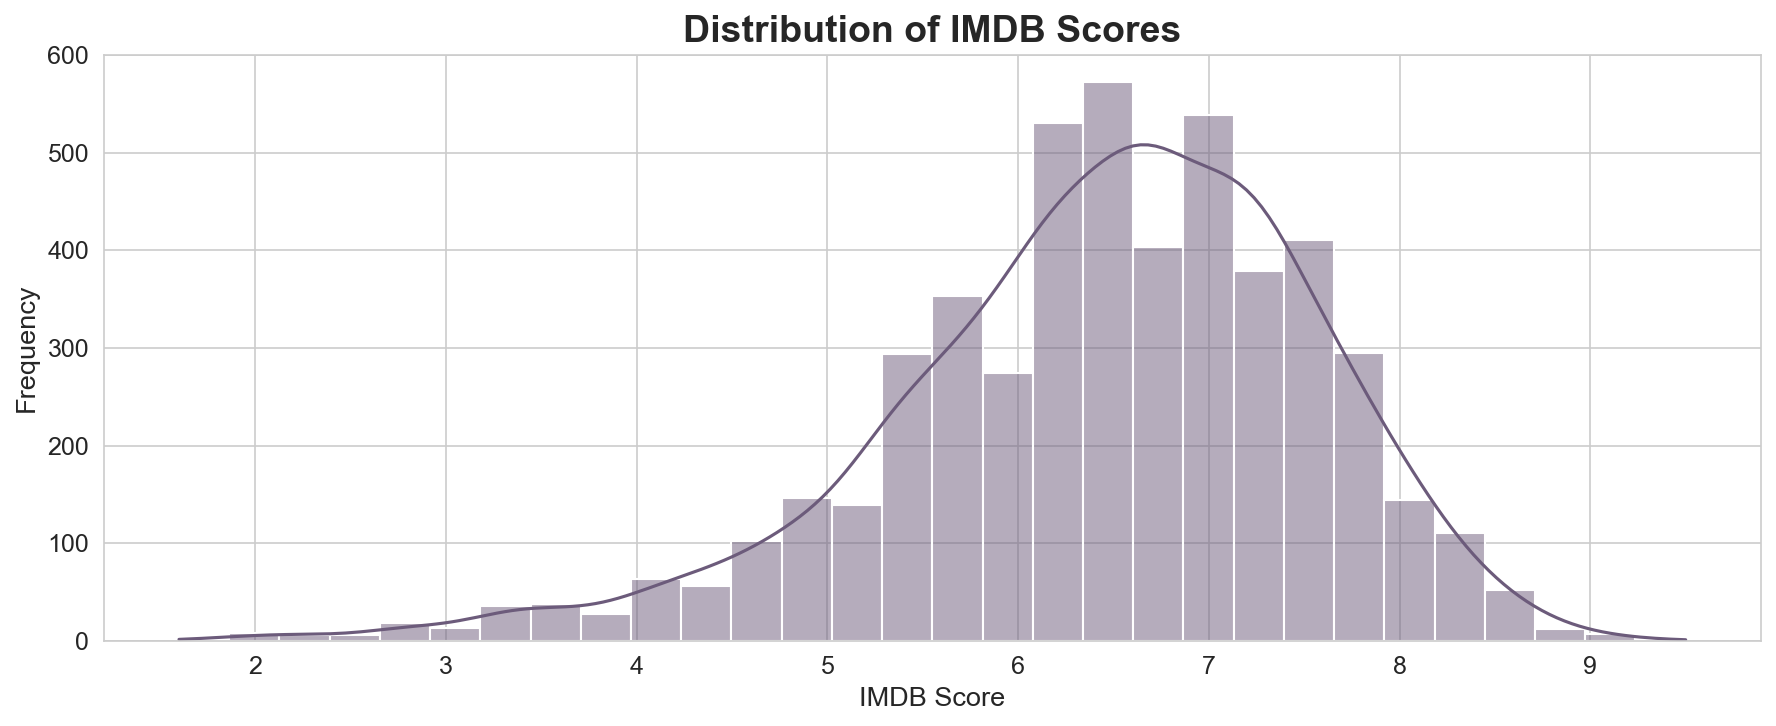

In [7]:
# Distribution of the target variable: IMDB Score
plt.figure(figsize=(12, 5))
sns.histplot(df['imdb_score'].dropna(), bins=30, kde=True, color='#6C5B7B')
plt.title('Distribution of IMDB Scores', fontsize=18, fontweight='bold')
plt.xlabel('IMDB Score', fontsize=13)
plt.ylabel('Frequency', fontsize=13)
plt.tight_layout()


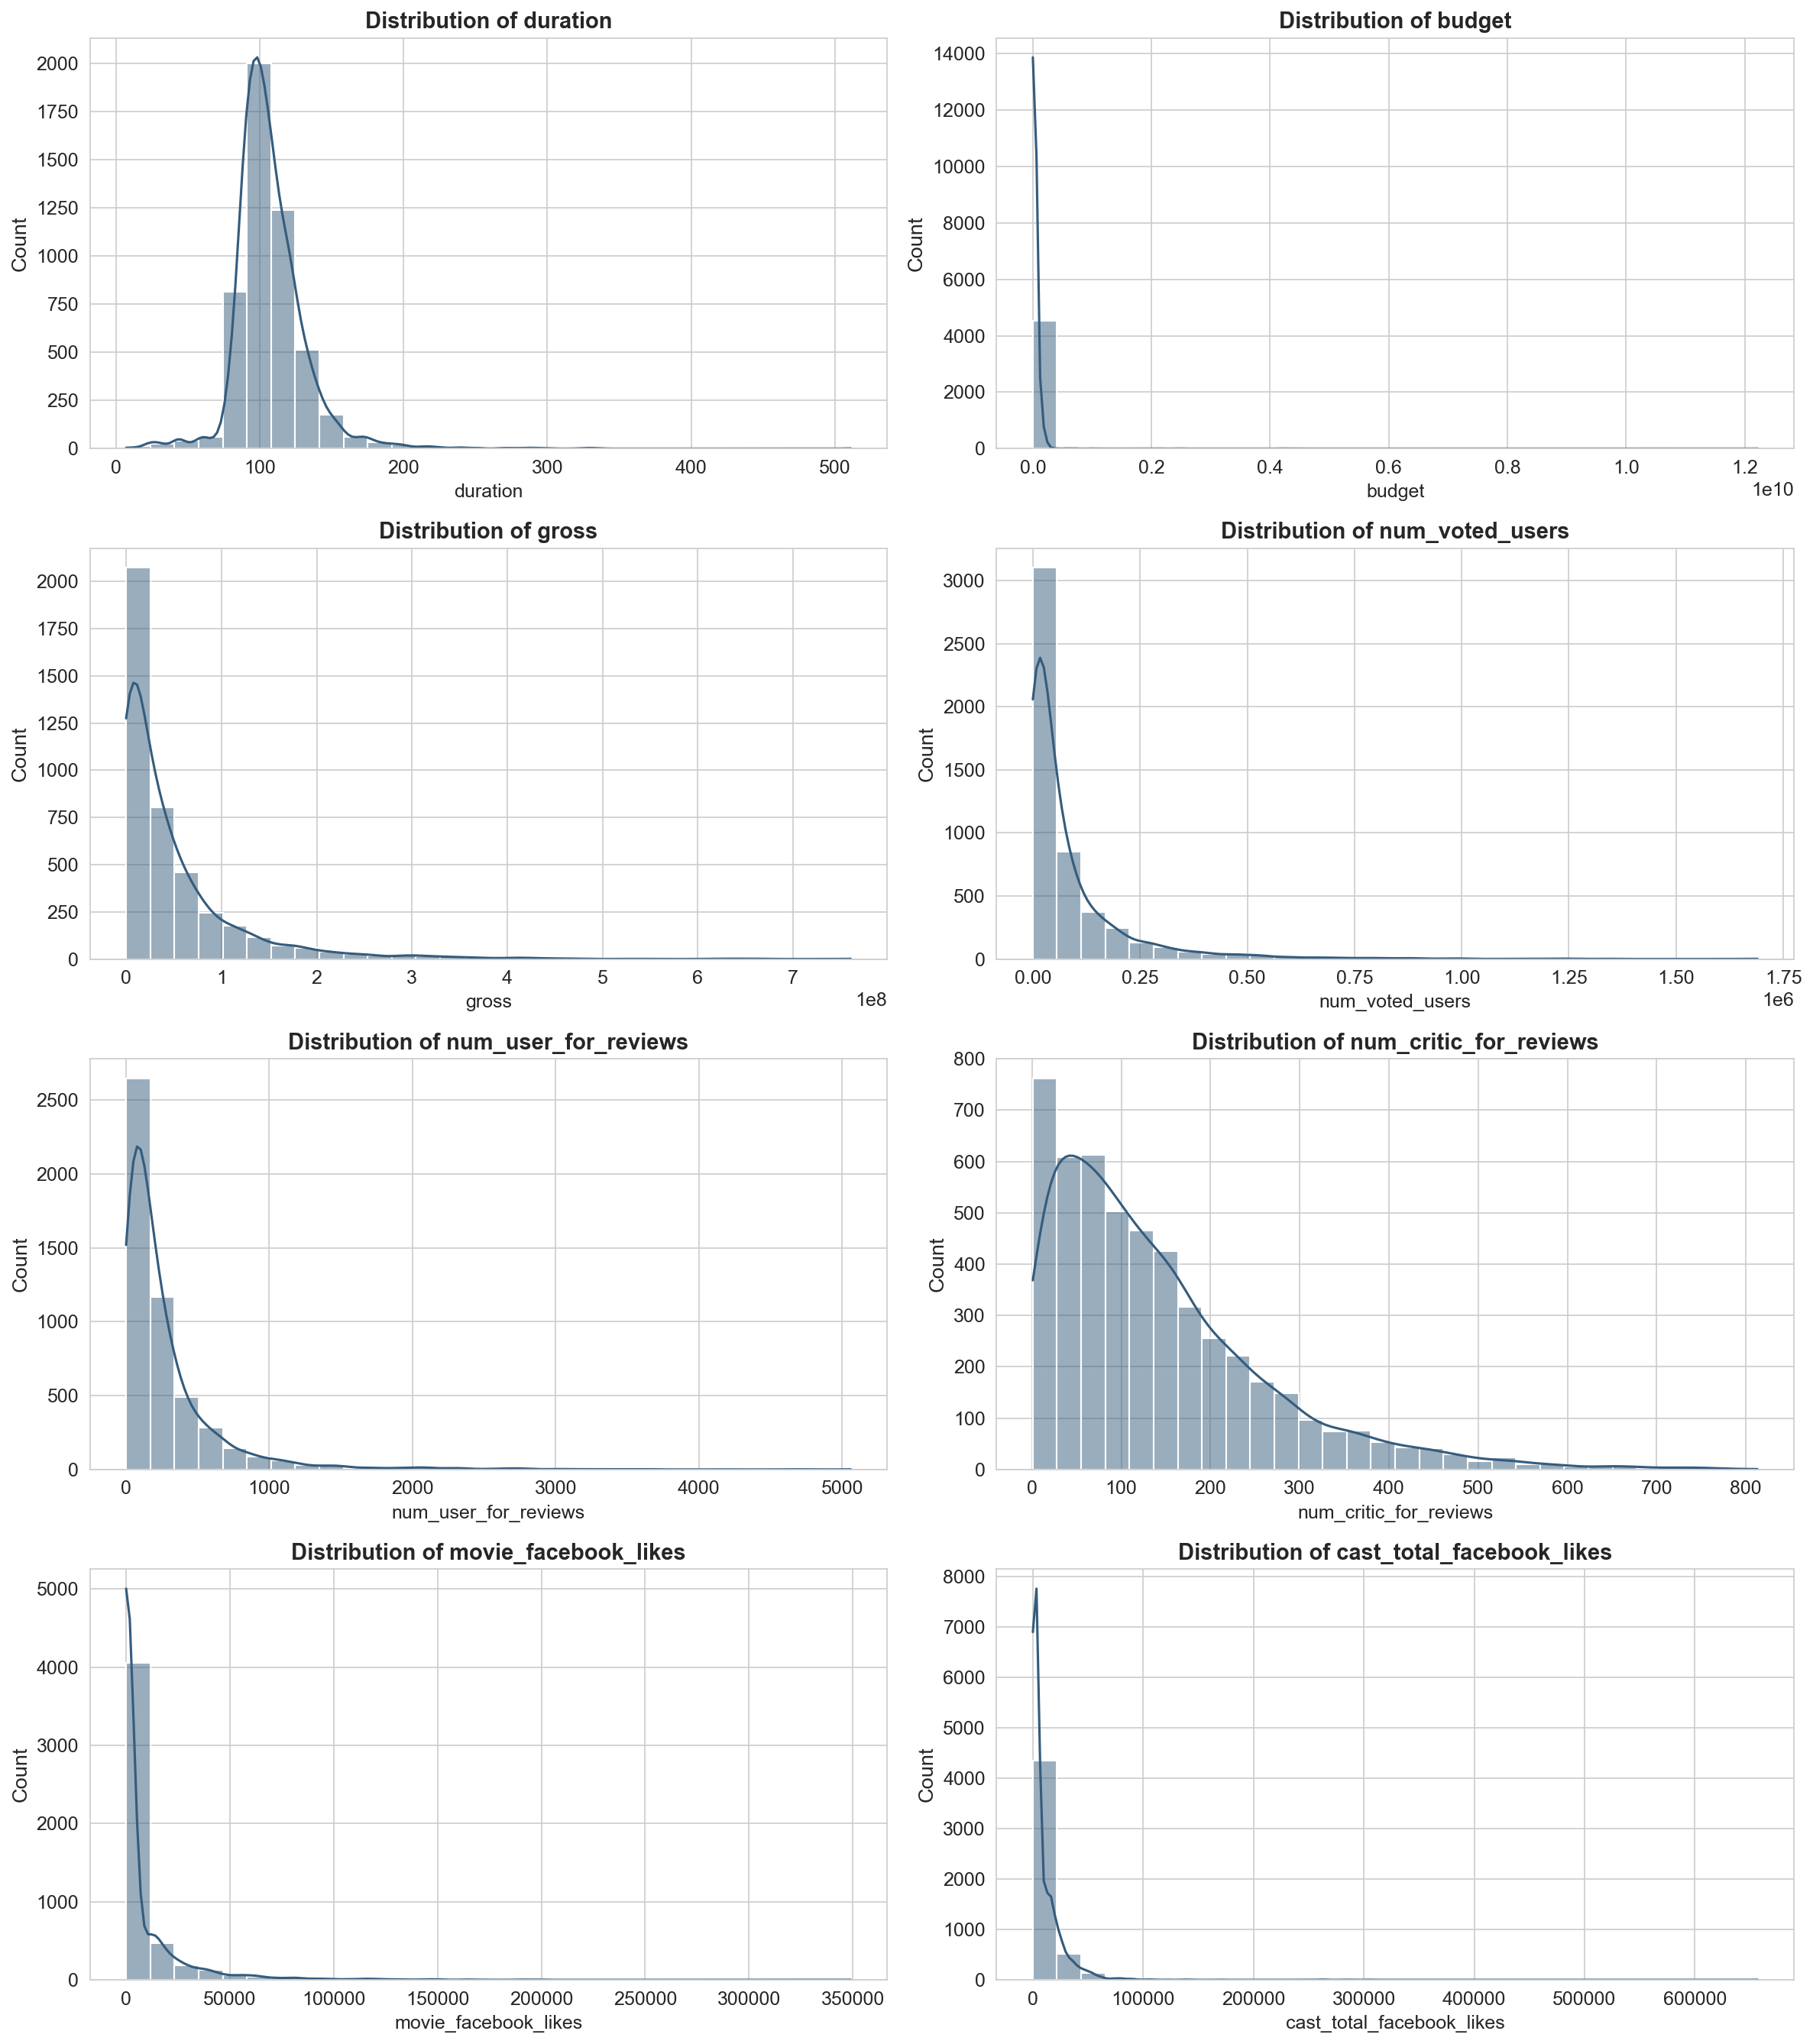

In [8]:
# Univariate analysis for key numerical features
num_features_to_plot = ['duration', 'budget', 'gross', 'num_voted_users',
                        'num_user_for_reviews', 'num_critic_for_reviews',
                        'movie_facebook_likes', 'cast_total_facebook_likes']

fig, axes = plt.subplots(nrows=4, ncols=2, figsize=(16, 18))
axes = axes.flatten()

for i, col in enumerate(num_features_to_plot):
    if col in df.columns:
        sns.histplot(df[col].dropna(), bins=30, kde=True, ax=axes[i], color="#355C7D")
        axes[i].set_title(f"Distribution of {col}", fontsize=14, fontweight="bold")
        axes[i].set_xlabel(col, fontsize=12)

plt.tight_layout()


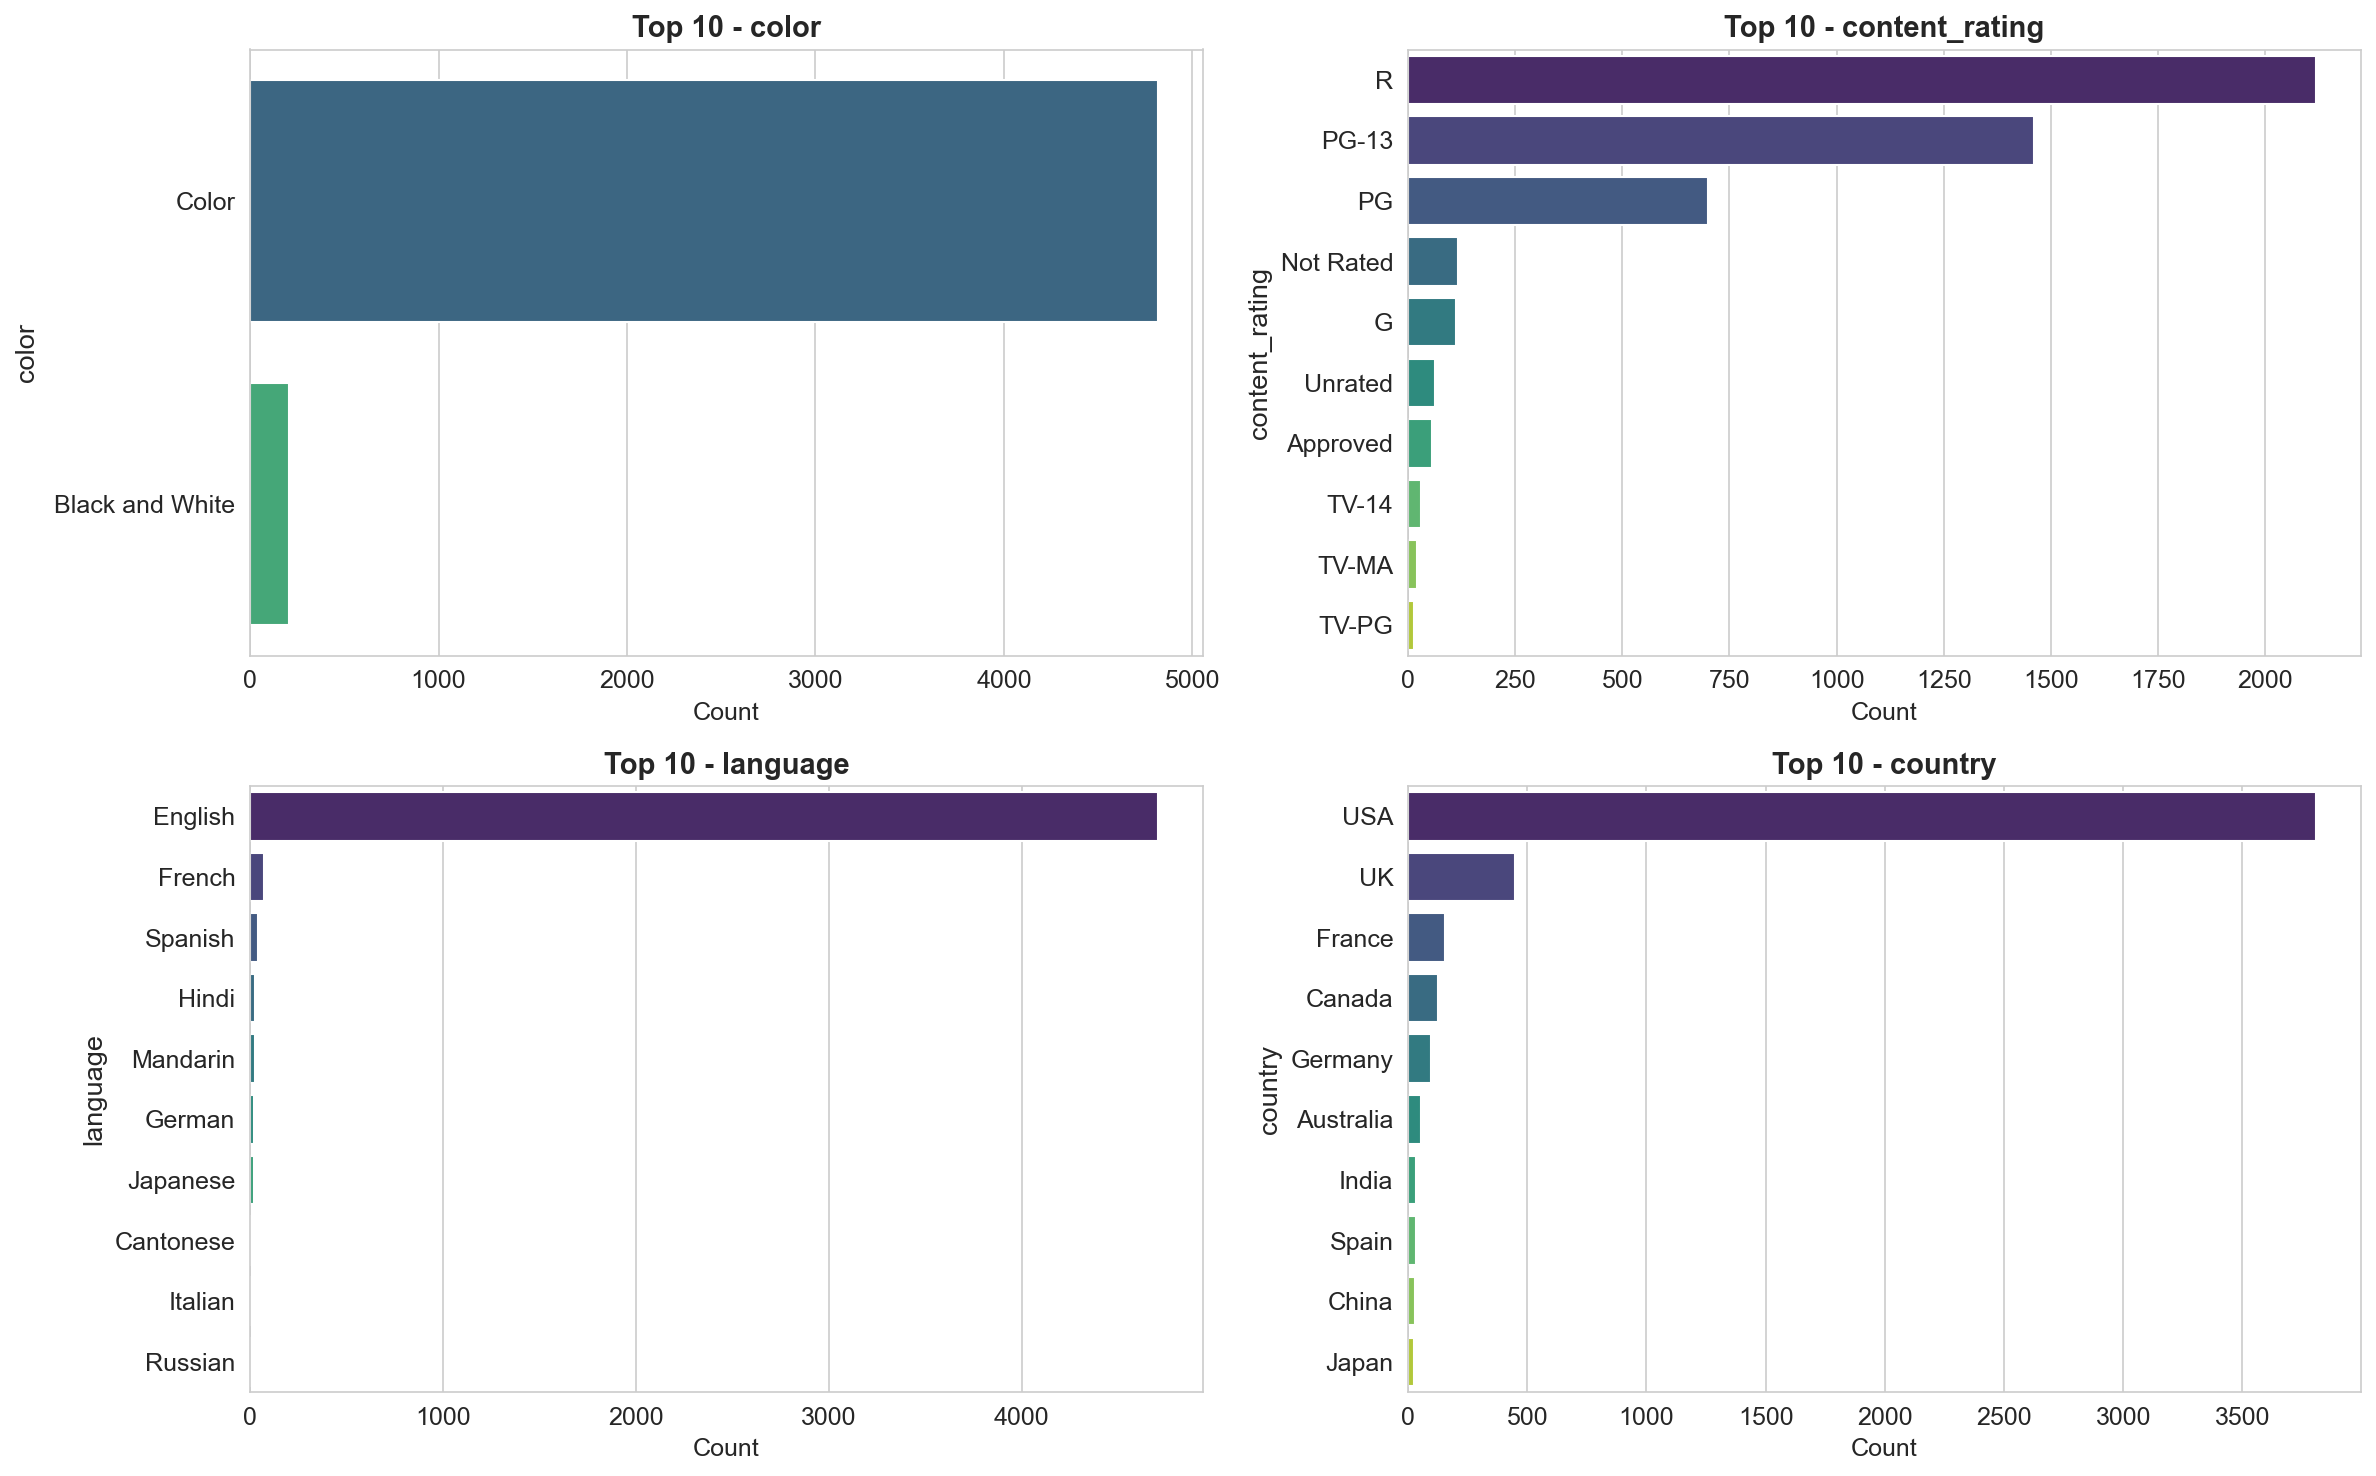

In [9]:
# Univariate analysis for key categorical features
cat_features_to_plot = ['color', 'content_rating', 'language', 'country']

fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(16, 10))
axes = axes.flatten()

for i, col in enumerate(cat_features_to_plot):
    if col in df.columns:
        top_vals = df[col].value_counts().head(10)
        sns.barplot(x=top_vals.values, y=top_vals.index, ax=axes[i], palette="viridis",
                    hue=top_vals.index, dodge=False, legend=False)
        axes[i].set_title(f"Top 10 - {col}", fontsize=14, fontweight="bold")
        axes[i].set_xlabel("Count", fontsize=12)

plt.tight_layout()


<div style="border-radius:8px; padding: 15px; background-color:#e8e4f0; color:#000000; font-size:115%; text-align:left">

<h3 align="left"><font color="#d4a017">Observations:</font></h3>

* **IMDB scores** are roughly normally distributed, centered around 6.0â€“7.0, with a left skew toward lower ratings.
* **Budget and gross** are heavily right-skewed â€” most movies have modest budgets, but a few blockbusters dominate.
* **Facebook likes** features are also right-skewed, with a small number of very popular movies/actors.
* **English** is the dominant language, and the **USA** is the dominant country of production.
* **Color** movies vastly outnumber black-and-white films.
</div>

<a id="step4_2"></a>
## <b><span style="color:#c0a36a">4.2 â€”</span><span style="color:#2b1055"> Bivariate Analysis (Features vs Target)</span></b>

<div style="border-radius:8px; padding: 15px; background-color:#e8e4f0; color:#000000; font-size:115%; text-align:left">
Before preprocessing, we create a temporary target variable to examine how features relate to movie success.
</div>

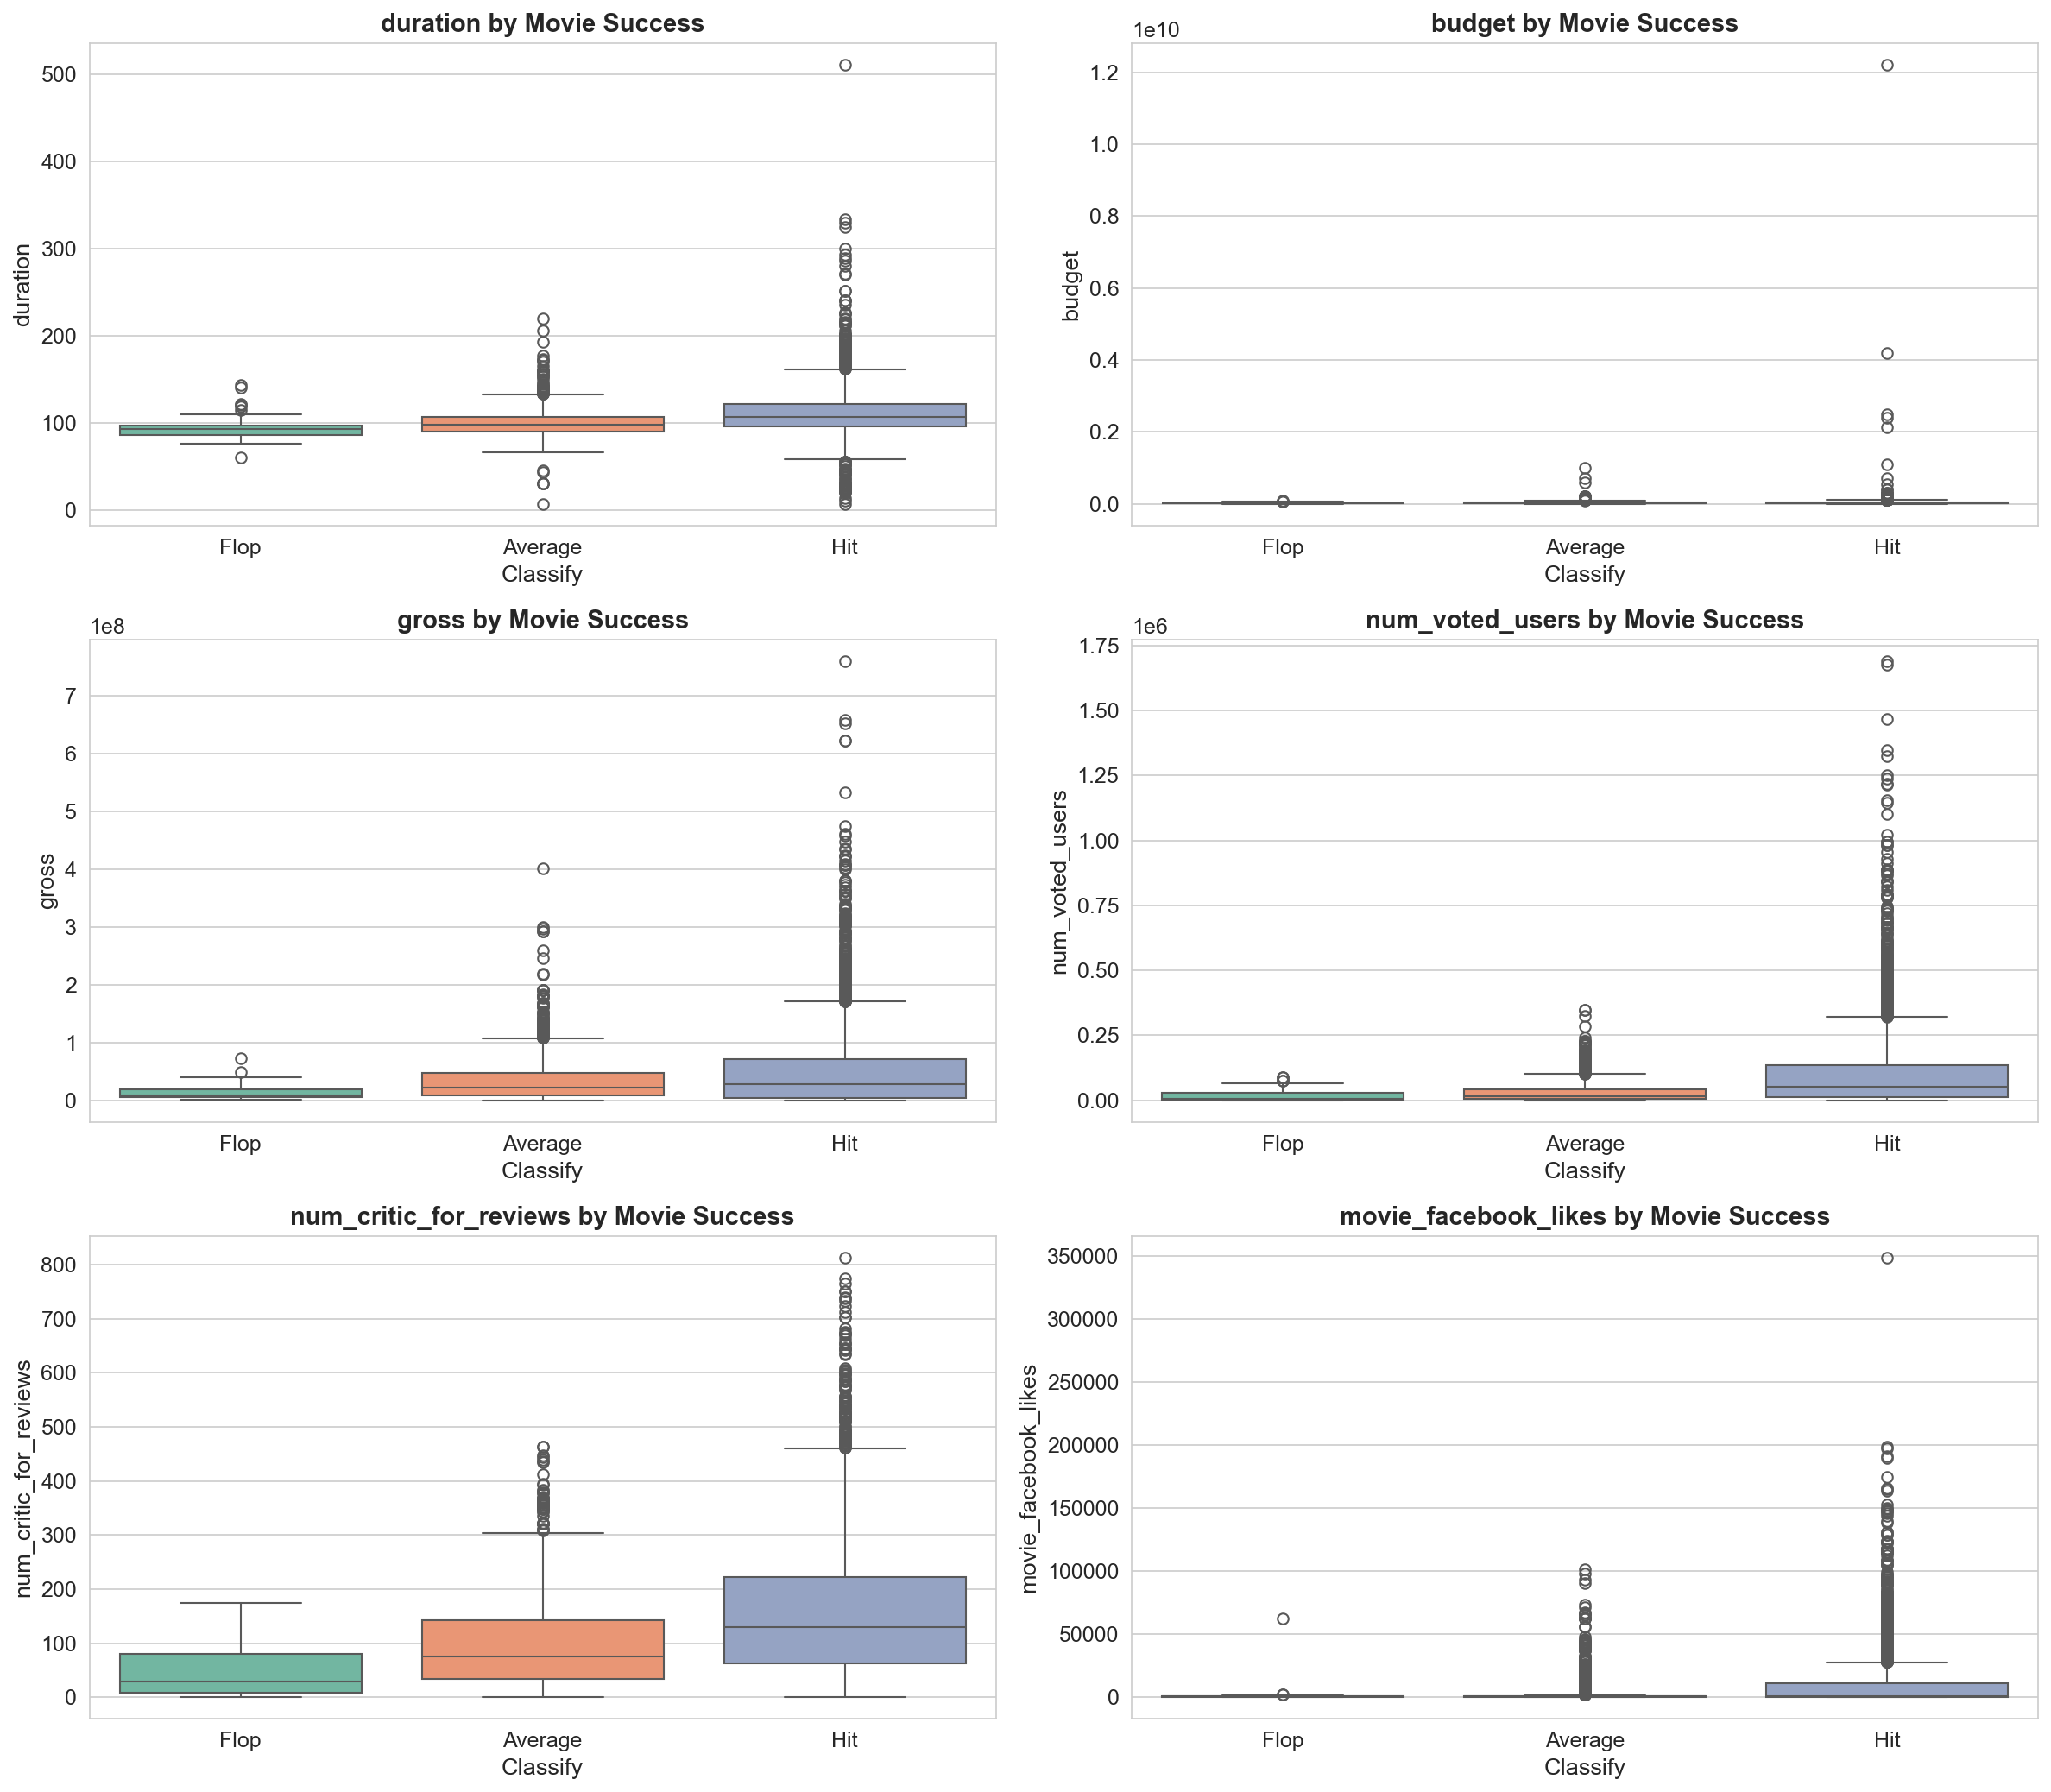

In [10]:
# Create temporary Classify column for bivariate analysis
temp_df = df.copy()
temp_df['Classify'] = pd.cut(temp_df['imdb_score'], bins=[0, 3, 6, 10],
                              labels=['Flop', 'Average', 'Hit'], include_lowest=True)

# Numerical features vs Target (boxplots)
bivariate_num = ['duration', 'budget', 'gross', 'num_voted_users',
                 'num_critic_for_reviews', 'movie_facebook_likes']

fig, axes = plt.subplots(nrows=3, ncols=2, figsize=(16, 14))
axes = axes.flatten()

for i, col in enumerate(bivariate_num):
    if col in temp_df.columns:
        sns.boxplot(data=temp_df, x='Classify', y=col, ax=axes[i],
                    order=['Flop', 'Average', 'Hit'], palette='Set2',
                    hue='Classify', legend=False)
        axes[i].set_title(f"{col} by Movie Success", fontsize=14, fontweight="bold")

plt.tight_layout()


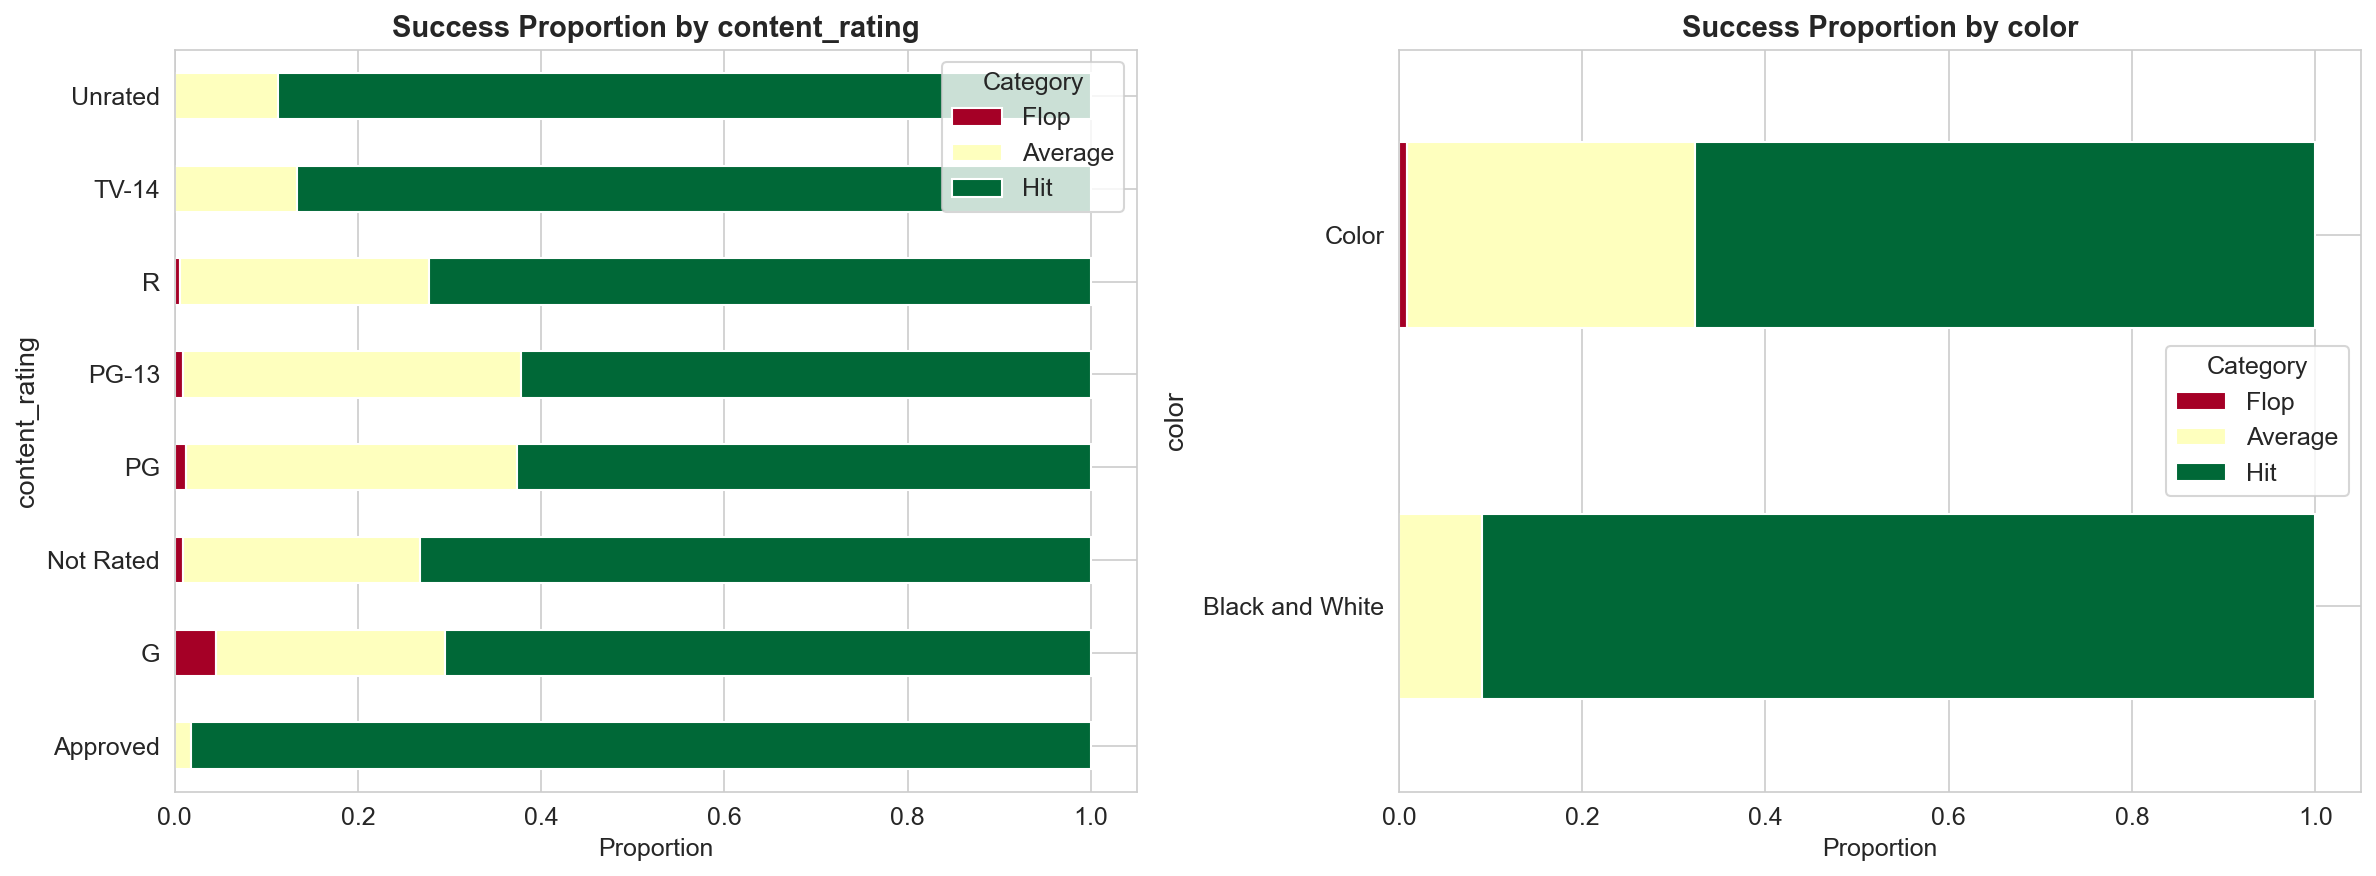

In [11]:
# Categorical features vs Target (stacked proportions)
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for i, col in enumerate(['content_rating', 'color']):
    if col in temp_df.columns:
        ct = pd.crosstab(temp_df[col], temp_df['Classify'], normalize='index')
        # Keep only top categories
        if len(ct) > 8:
            top_idx = temp_df[col].value_counts().head(8).index
            ct = ct.loc[ct.index.isin(top_idx)]
        ct[['Flop', 'Average', 'Hit']].plot(kind='barh', stacked=True,
                                             ax=axes[i], colormap='RdYlGn')
        axes[i].set_title(f'Success Proportion by {col}', fontsize=14, fontweight='bold')
        axes[i].set_xlabel('Proportion', fontsize=12)
        axes[i].legend(title='Category')

plt.tight_layout()
plt.show()



<div style="border-radius:8px; padding: 15px; background-color:#e8e4f0; color:#000000; font-size:115%; text-align:left">

<h3 align="left"><font color="#d4a017">Observations:</font></h3>

* **Hit movies** tend to have higher budgets, grosses, vote counts, and critic reviews than Average or Flop movies.
* **Duration** shows a clear trend: Hit movies are generally longer; very short films often fall into the Flop category.
* **Content ratings** like PG-13 and R dominate the dataset, with G-rated films having a relatively higher Hit proportion.
* **Color vs B&W**: Color films make up the vast majority, and both categories show similar success distributions.
</div>

<a id="step4_3"></a>
## <b><span style="color:#c0a36a">4.3 â€”</span><span style="color:#2b1055"> Correlation Heatmap</span></b>

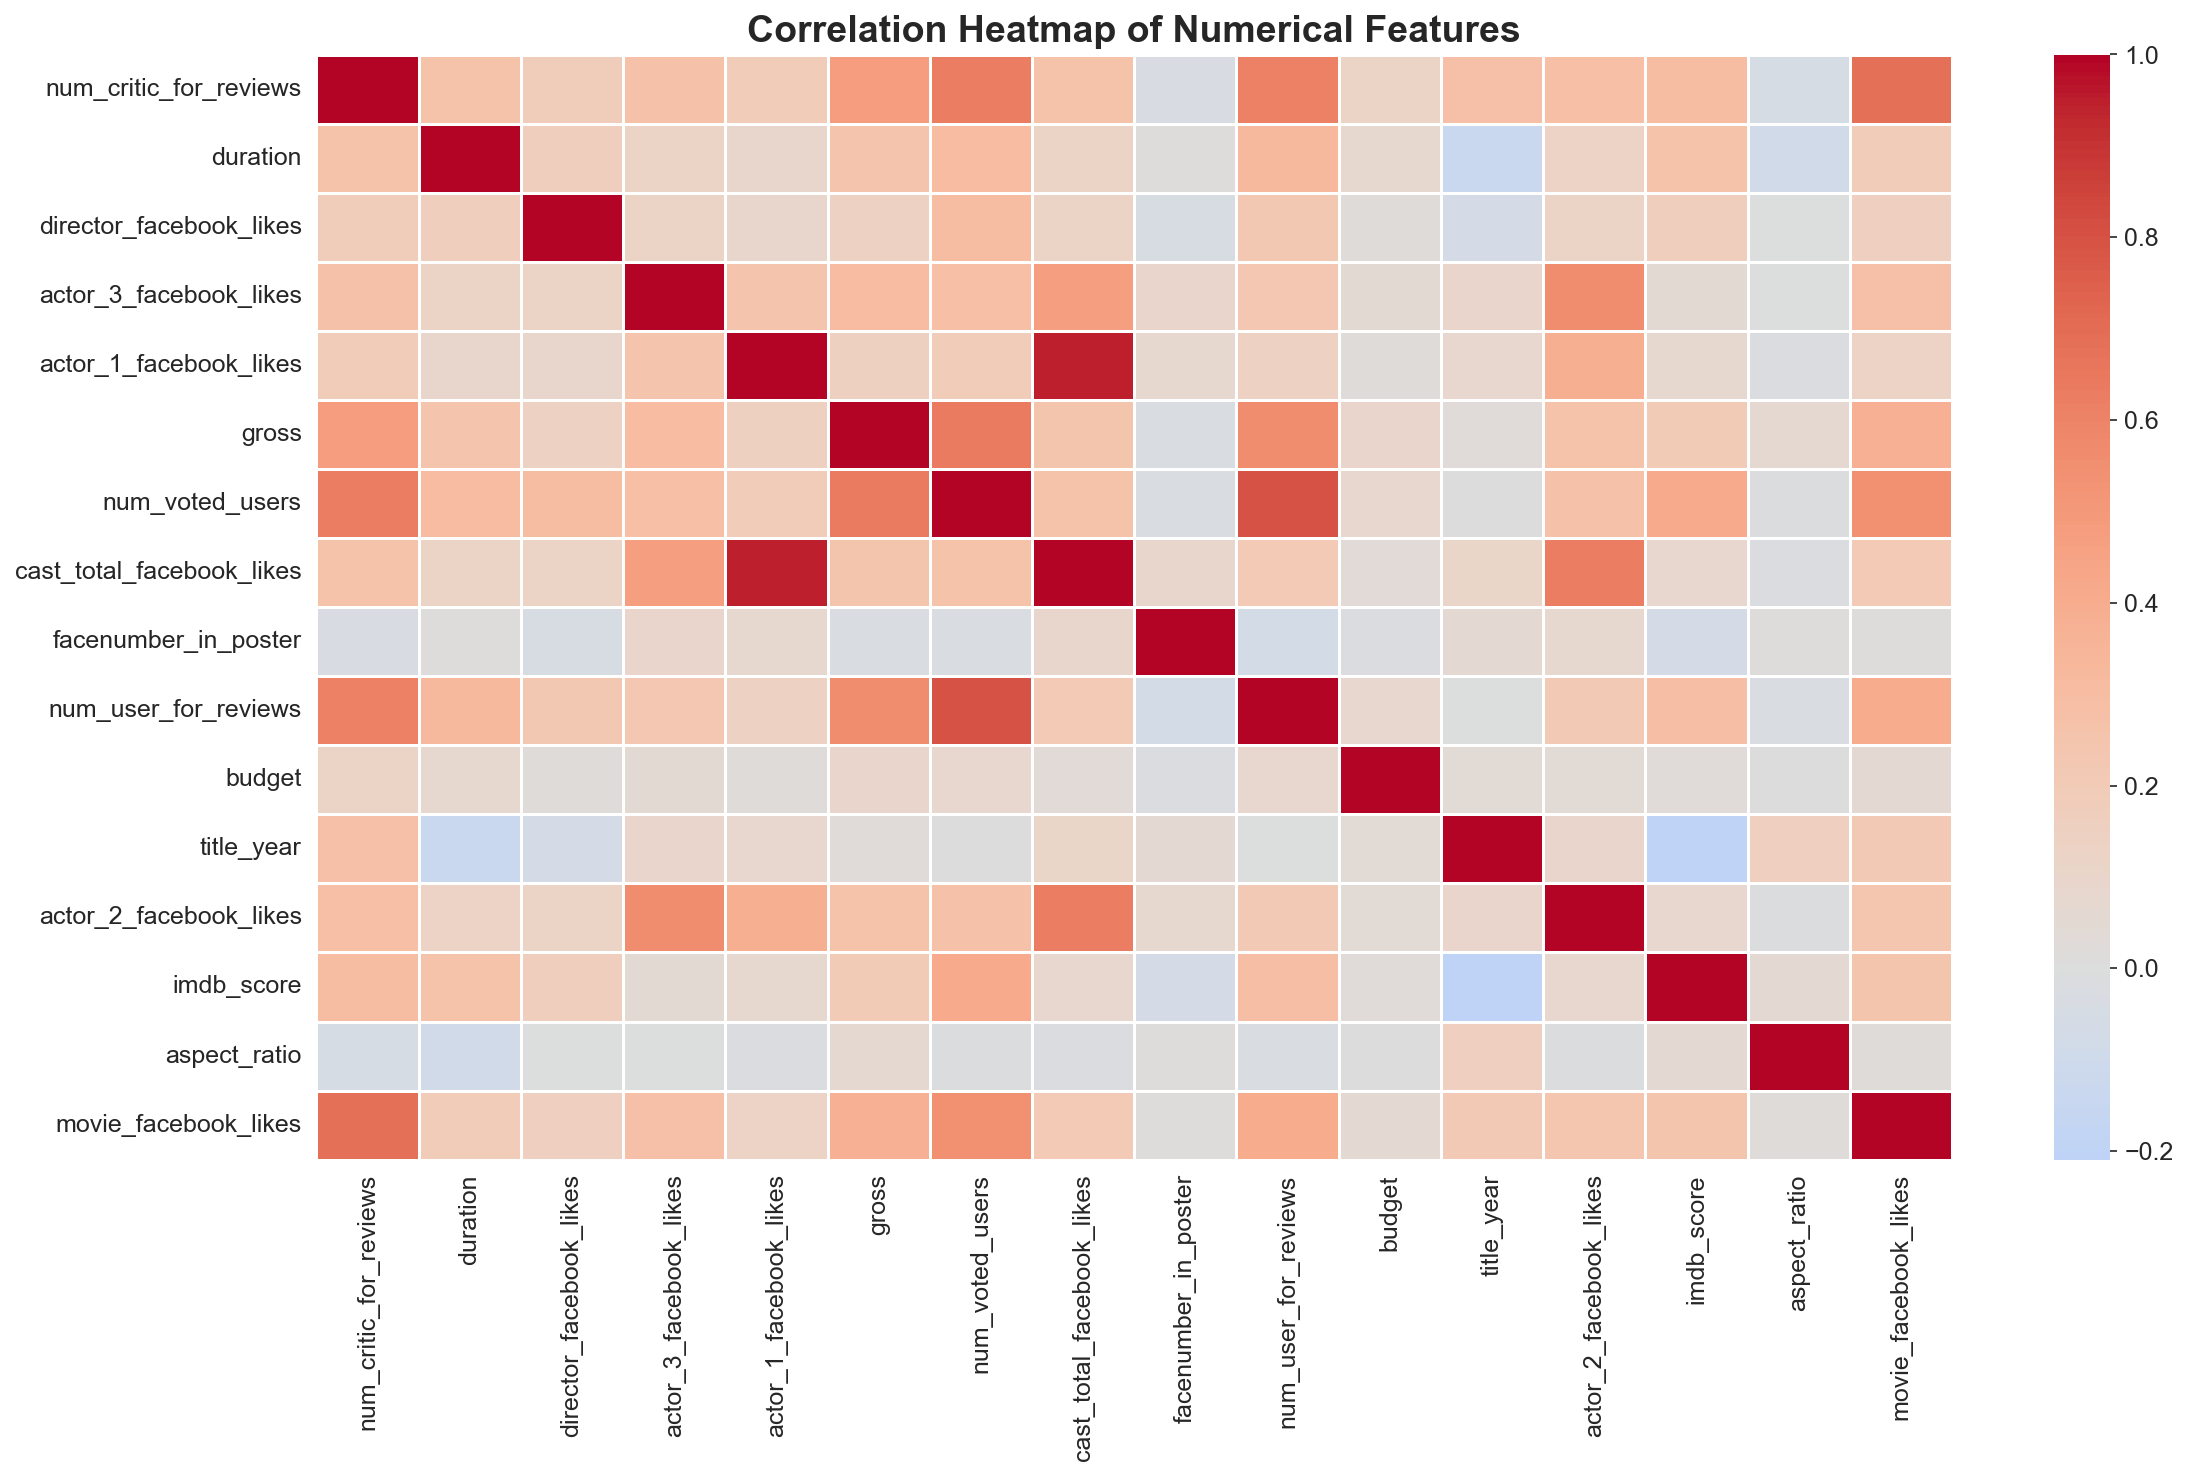

In [12]:
# Correlation heatmap of numerical features
plt.figure(figsize=(16, 10))
corr_matrix = df.select_dtypes(include=[np.number]).corr()
sns.heatmap(corr_matrix, annot=False, cmap='coolwarm', linewidths=0.5, center=0)
plt.title('Correlation Heatmap of Numerical Features', fontsize=18, fontweight='bold')
plt.tight_layout()


<div style="border-radius:8px; padding: 15px; background-color:#e8e4f0; color:#000000; font-size:115%; text-align:left">

<h3 align="left"><font color="#d4a017">Observations:</font></h3>

* `num_voted_users` and `num_user_for_reviews` are strongly correlated, indicating potential multicollinearity.
* `cast_total_facebook_likes` correlates highly with individual actor Facebook likes columns.
* These highly correlated features will be addressed in the preprocessing step.
</div>

<a id="step5"></a>
# <p style="background-color:#2b1055; font-family:Trebuchet MS, sans-serif; color:#ffffff; font-size:150%; text-align:center; border-radius:10px;">Phase 5: Data Preprocessing</p>

[â†‘ Back to Top](#contents_table)

<a id="step5_1"></a>
## <b><span style="color:#c0a36a">5.1 â€”</span><span style="color:#2b1055"> Missing Value Treatment</span></b>

In [13]:
# Drop rows where the target variable is missing
df = df.dropna(subset=['imdb_score'])

# Drop columns that offer no predictive value
if 'movie_imdb_link' in df.columns:
    df = df.drop(columns=['movie_imdb_link'])

# Fill missing numericals with median, categoricals with mode/Unknown
num_cols = df.select_dtypes(include=[np.number]).columns
cat_cols = df.select_dtypes(include=['object']).columns

for col in num_cols:
    df.loc[:, col] = df[col].fillna(df[col].median())
for col in cat_cols:
    if col in ['director_name', 'actor_1_name', 'actor_2_name', 'actor_3_name', 'plot_keywords']:
        df.loc[:, col] = df[col].fillna('Unknown')
    else:
        df.loc[:, col] = df[col].fillna(df[col].mode()[0])

print(f"Missing values after treatment: {df.isnull().sum().sum()}")


Missing values after treatment: 0


<a id="step5_2"></a>
## <b><span style="color:#c0a36a">5.2 â€”</span><span style="color:#2b1055"> Target Variable Creation</span></b>

<div style="border-radius:8px; padding: 15px; background-color:#e8e4f0; color:#000000; font-size:115%; text-align:left">
We categorize IMDB scores into three success tiers: <b>Flop</b> (1-3), <b>Average</b> (3-6), and <b>Hit</b> (6-10). The original `imdb_score` column is then dropped to prevent data leakage.
</div>

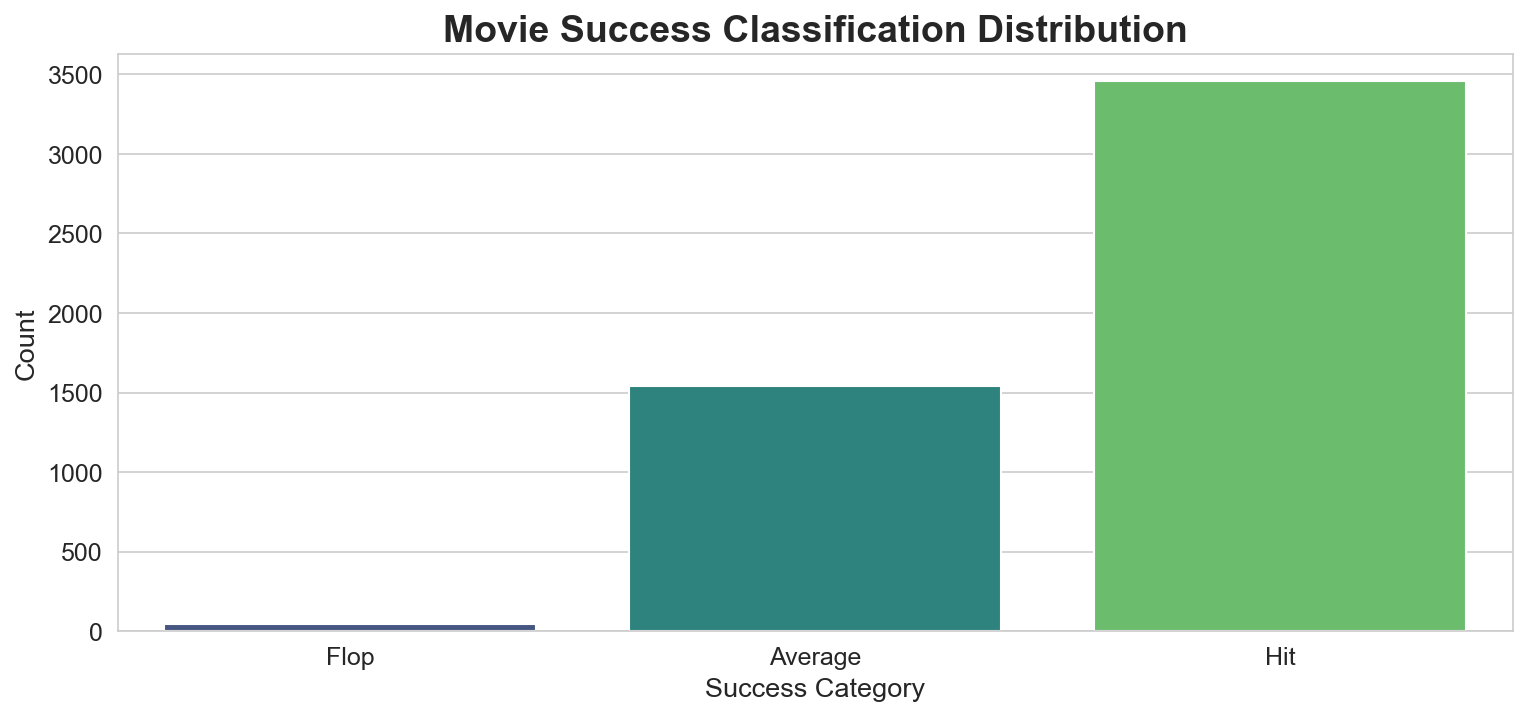

In [14]:
bins = [0, 3, 6, 10]
labels = ['Flop', 'Average', 'Hit']
df['Classify'] = pd.cut(df['imdb_score'], bins=bins, labels=labels, include_lowest=True)

# Visualize target distribution
plt.figure(figsize=(12, 5))
sns.countplot(data=df, x='Classify', hue='Classify', palette='viridis',
              order=['Flop', 'Average', 'Hit'], legend=False)
plt.title('Movie Success Classification Distribution', fontsize=18, fontweight='bold')
plt.xlabel('Success Category', fontsize=13)
plt.ylabel('Count', fontsize=13)
plt.show()

# Drop imdb_score to prevent data leakage
df = df.drop(columns=['imdb_score'])


<a id="step5_3"></a>
## <b><span style="color:#c0a36a">5.3 â€”</span><span style="color:#2b1055"> Outlier Treatment</span></b>

<div style="border-radius:8px; padding: 15px; background-color:#e8e4f0; color:#000000; font-size:115%; text-align:left">
We detect outliers in continuous numerical features using the <b>IQR method</b>. In the current workflow, outliers are reviewed but intentionally <b>not capped</b>, because tree-based models can leverage extreme values.
</div>

In [15]:
# Identify continuous numerical features for outlier treatment
continuous_features = ['duration', 'num_critic_for_reviews', 'num_user_for_reviews',
                       'num_voted_users', 'movie_facebook_likes',
                       'director_facebook_likes', 'actor_1_facebook_likes',
                       'actor_2_facebook_likes', 'actor_3_facebook_likes',
                       'cast_total_facebook_likes', 'facenumber_in_poster']
# Only consider columns that actually exist in df
continuous_features = [c for c in continuous_features if c in df.columns]
# Detect outliers using IQR
Q1 = df[continuous_features].quantile(0.25)
Q3 = df[continuous_features].quantile(0.75)
IQR = Q3 - Q1
outlier_counts = ((df[continuous_features] < (Q1 - 1.5 * IQR)) | (df[continuous_features] > (Q3 + 1.5 * IQR))).sum()
print("Outlier counts per feature:")
print(outlier_counts[outlier_counts > 0].sort_values(ascending=False))
# Outliers are kept as-is because tree-based models (RF, XGBoost) use them effectively.
print("\nOutliers detected. We will NOT cap them to preserve valuable information for our tree-based models.")


Outlier counts per feature:
movie_facebook_likes         1173
actor_2_facebook_likes        638
director_facebook_likes       627
num_voted_users               468
num_user_for_reviews          396
cast_total_facebook_likes     354
duration                      241
facenumber_in_poster          210
num_critic_for_reviews        203
actor_3_facebook_likes        173
actor_1_facebook_likes        170
dtype: int64

Outliers detected. We will NOT cap them to preserve valuable information for our tree-based models.


<div style="border-radius:8px; padding: 15px; background-color:#e8e4f0; color:#000000; font-size:115%; text-align:left">

<h3 align="left"><font color="#d4a017">Key Takeaway:</font></h3>

Several features like `movie_facebook_likes`, `cast_total_facebook_likes`, and `num_voted_users` had significant outliers. However, because our strongest predictive models (like Random Forest and XGBoost) are tree-based algorithms, they are inherently robust to outliers and can use these extreme values to make better splits. Therefore, we elect to **detect but NOT cap** the outliers, preserving all original data signals.
</div>


<a id="step5_4"></a>
## <b><span style="color:#c0a36a">5.4 â€”</span><span style="color:#2b1055"> Multicollinearity Treatment</span></b>

In [16]:
# Identify highly correlated numerical features (threshold > 0.80)
num_features = df.select_dtypes(include=[np.number])
corr_matrix = num_features.corr().abs()
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
to_drop = [column for column in upper.columns if any(upper[column] > 0.80)]
print(f"Highly correlated columns identified and dropped: {to_drop}")

# Actually remove the multicollinear columns
df = df.drop(columns=to_drop)


Highly correlated columns identified and dropped: ['cast_total_facebook_likes']


<a id="step5_5"></a>
## <b><span style="color:#c0a36a">5.5 â€”</span><span style="color:#2b1055"> Encoding & Scaling</span></b>

In [17]:
# Prepare X (features) and y (target)
X = df.drop(columns=['Classify'])
y = df['Classify']

# Split into Train and Test sets BEFORE encoding to prevent data leakage
print("Splitting data into training and testing sets...")
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

X_train = X_train.copy()
X_test = X_test.copy()

# Use OrdinalEncoder for categoricals to handle high cardinality appropriately without leakage
from sklearn.preprocessing import OrdinalEncoder, StandardScaler
cat_cols = X_train.select_dtypes(include=['object', 'category']).columns

print("Encoding categorical variables safely...")
oe = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)
if len(cat_cols) > 0:
    X_train[cat_cols] = oe.fit_transform(X_train[cat_cols].astype(str))
    X_test[cat_cols] = oe.transform(X_test[cat_cols].astype(str))

# Ensure all data is numeric before scaling
X_train = X_train.astype(float)
X_test = X_test.astype(float)

# Scale features using only training data (prevents data leakage)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
print(f"Training set: {X_train_scaled.shape[0]} samples")


Splitting data into training and testing sets...
Encoding categorical variables safely...
Training set: 4034 samples


<a id="step6"></a>
# <p style="background-color:#2b1055; font-family:Trebuchet MS, sans-serif; color:#ffffff; font-size:150%; text-align:center; border-radius:10px;">Phase 6: Model Building & Evaluation</p>

[â†‘ Back to Top](#contents_table)

<div style="border-radius:8px; padding: 15px; background-color:#e8e4f0; color:#000000; font-size:115%; text-align:left">
We evaluate our models primarily using the **Weighted F1-Score**. Because our target variable has significant class imbalance (many more Average/Hit movies than Flops), raw Test Accuracy is misleading. The F1-Score balances Precision and Recall across all classes. We also examine **Classification Reports** and **Confusion Matrices** to understand model performance across different success categories. We define a helper function to evaluate each model consistently.
</div>

In [18]:
def evaluate_model(model, X_train, X_test, y_train, y_test, model_name):
    """Evaluates model on train and test data and returns comparison metrics including F1."""
    from sklearn.metrics import f1_score, accuracy_score, classification_report
    
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)
    
    train_acc = accuracy_score(y_train, y_train_pred)
    test_acc = accuracy_score(y_test, y_test_pred)
    train_f1 = f1_score(y_train, y_train_pred, average='weighted')
    test_f1 = f1_score(y_test, y_test_pred, average='weighted')
    
    print(f"\n--- {model_name} ---")
    print(f"Training Accuracy: {train_acc:.4f} | Training Weighted F1: {train_f1:.4f}")
    print(f"Test Accuracy:     {test_acc:.4f} | Test Weighted F1:     {test_f1:.4f}")
    print(f"\nClassification Report (Test Set):")
    print(classification_report(y_test, y_test_pred, zero_division=0))
    
    return pd.DataFrame({
        "Model": [model_name],
        "Test Accuracy": [round(test_acc, 4)],
        "Test F1 (Weighted)": [round(test_f1, 4)]
    })


<a id="step6_1"></a>
## <b><span style="color:#c0a36a">6.1 â€”</span><span style="color:#2b1055"> Logistic Regression (Baseline)</span></b>


--- Logistic Regression ---
Training Accuracy: 0.6158 | Training Weighted F1: 0.6705
Test Accuracy:     0.5719 | Test Weighted F1:     0.6267

Classification Report (Test Set):
              precision    recall  f1-score   support

     Average       0.45      0.62      0.52       308
        Flop       0.04      0.78      0.08         9
         Hit       0.90      0.55      0.68       692

    accuracy                           0.57      1009
   macro avg       0.46      0.65      0.43      1009
weighted avg       0.75      0.57      0.63      1009



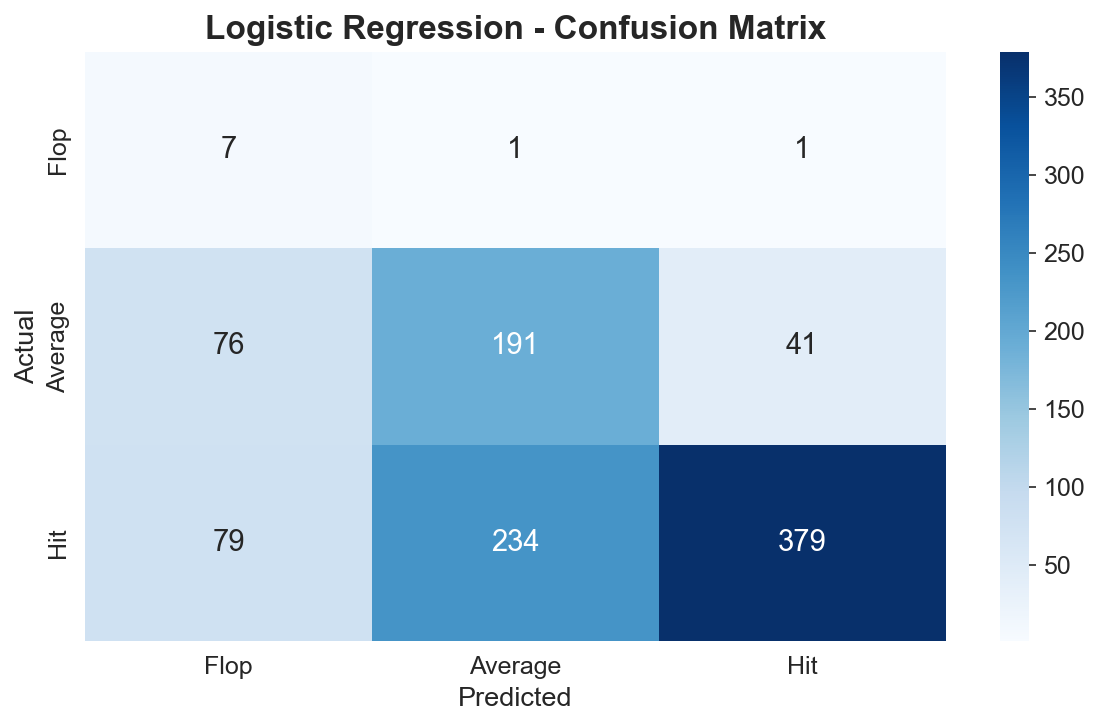

In [19]:
log_model = LogisticRegression(max_iter=12000, random_state=42, class_weight='balanced', solver='saga')
log_model.fit(X_train_scaled, y_train)
log_preds = log_model.predict(X_test_scaled)
log_eval = evaluate_model(log_model, X_train_scaled, X_test_scaled, y_train, y_test, "Logistic Regression")

# Confusion Matrix
plt.figure(figsize=(8, 5))
cm_log = confusion_matrix(y_test, log_preds, labels=['Flop', 'Average', 'Hit'])
sns.heatmap(cm_log, annot=True, fmt='d', cmap='Blues', annot_kws={'size': 14},
            xticklabels=['Flop', 'Average', 'Hit'], yticklabels=['Flop', 'Average', 'Hit'])
plt.title('Logistic Regression - Confusion Matrix', fontsize=16, fontweight='bold')
plt.ylabel('Actual', fontsize=13)
plt.xlabel('Predicted', fontsize=13)
plt.tight_layout()


<a id="step6_2"></a>
## <b><span style="color:#c0a36a">6.2 </span><span style="color:#2b1055"> Random Forest Classifier</span></b>


--- Random Forest ---
Training Accuracy: 0.8580 | Training Weighted F1: 0.8622
Test Accuracy:     0.7512 | Test Weighted F1:     0.7559

Classification Report (Test Set):
              precision    recall  f1-score   support

     Average       0.57      0.76      0.65       308
        Flop       0.00      0.00      0.00         9
         Hit       0.87      0.76      0.81       692

    accuracy                           0.75      1009
   macro avg       0.48      0.51      0.49      1009
weighted avg       0.77      0.75      0.76      1009



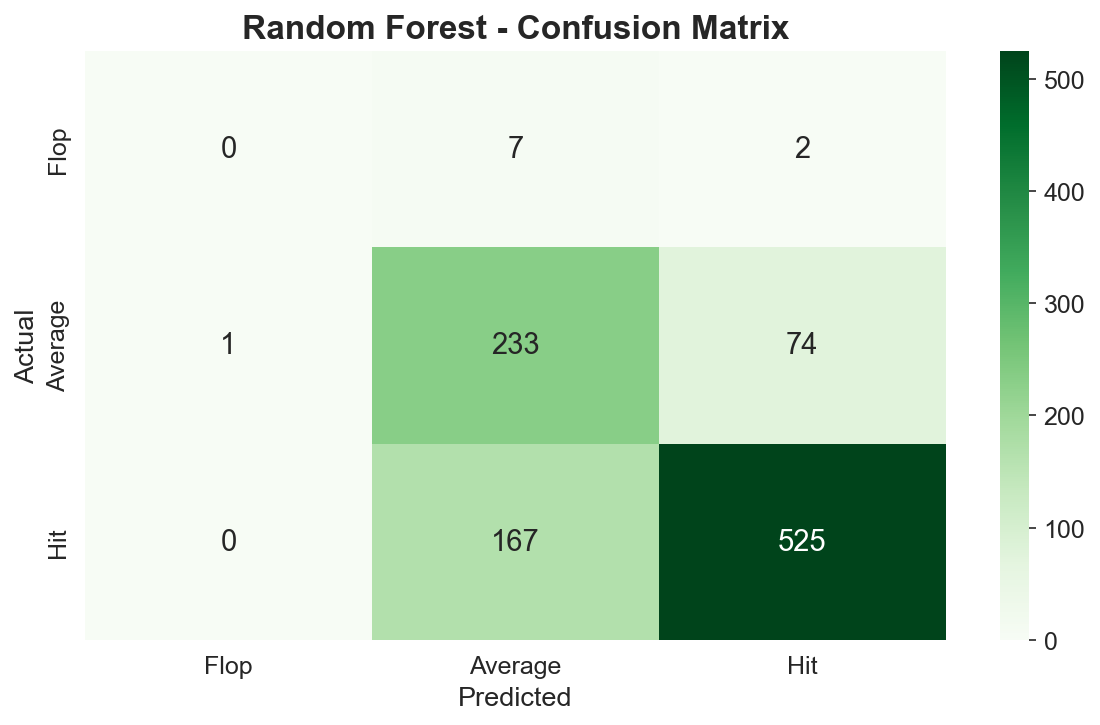

In [20]:
rf_model = RandomForestClassifier(
    n_estimators=200, 
    max_depth=8, 
    min_samples_split=10, 
    min_samples_leaf=5, 
    random_state=42, 
    class_weight='balanced', 
    n_jobs=-1
)
rf_model.fit(X_train, y_train)
rf_preds = rf_model.predict(X_test)
rf_eval = evaluate_model(rf_model, X_train, X_test, y_train, y_test, "Random Forest")

# Confusion Matrix
plt.figure(figsize=(8, 5))
cm_rf = confusion_matrix(y_test, rf_preds, labels=['Flop', 'Average', 'Hit'])
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Greens', annot_kws={'size': 14},
            xticklabels=['Flop', 'Average', 'Hit'], yticklabels=['Flop', 'Average', 'Hit'])
plt.title('Random Forest - Confusion Matrix', fontsize=16, fontweight='bold')
plt.ylabel('Actual', fontsize=13)
plt.xlabel('Predicted', fontsize=13)
plt.tight_layout()


<a id="step6_3"></a>
## <b><span style="color:#c0a36a">6.3 â€”</span><span style="color:#2b1055"> Optimized Model Search (mesh_utils)</span></b>

<div style="border-radius:8px; padding: 15px; background-color:#e8e4f0; color:#000000; font-size:115%; text-align:left">
Using a custom utility (`mesh_utils_optimized`) that performs <b>RandomizedSearchCV</b> across multiple algorithms (Random Forest, XGBoost, AdaBoost, SVM, Logistic Regression) to find the best-performing model automatically.
</div>

In [21]:
# Advanced Hyperparameter Tuning & Model Selection
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, f1_score

# Target Encoding
le_target = LabelEncoder()
y_train_encoded = le_target.fit_transform(y_train)
y_test_encoded = le_target.transform(y_test)

# Automated Model Hunt using F1-Score to handle class imbalance
import sys
sys.path.append('./ml_utils')
import mesh_utils_optimized
best_model_results = mesh_utils_optimized.find_best_model(
    X_train_scaled, y_train_encoded, 
    problem_type='classification', 
    metric='f1', 
    n_iter=40, 
    x_test=X_test_scaled, 
    y_test=y_test_encoded
)

y_pred_best_numeric = best_model_results['trained_model'].predict(X_test_scaled)
y_pred_best = le_target.inverse_transform(y_pred_best_numeric)

print(f"\nFINAL ENGINE: {best_model_results['best_model_name'].upper()}")
print(f"Validation F1 (Weighted): {f1_score(y_test, y_pred_best, average='weighted'):.4f}")
print(f"Validation Accuracy: {accuracy_score(y_test, y_pred_best):.4f}")


Training models for classification using f1 (RandomizedSearchCV)...

FINAL ENGINE: XGBOOST
Validation F1 (Weighted): 0.7801
Validation Accuracy: 0.7790


<a id="step7"></a>
# <p style="background-color:#2b1055; font-family:Trebuchet MS, sans-serif; color:#ffffff; font-size:150%; text-align:center; border-radius:10px;">Phase 7: Model Comparison</p>

[â†‘ Back to Top](#contents_table)


Benchmarking Matrix:


,Model,Test Accuracy,Test F1 (Weighted)
0,Logistic Regression,0.5719,0.6267
1,Random Forest,0.7512,0.7559
2,Mesh (xgboost),0.7790,0.7801


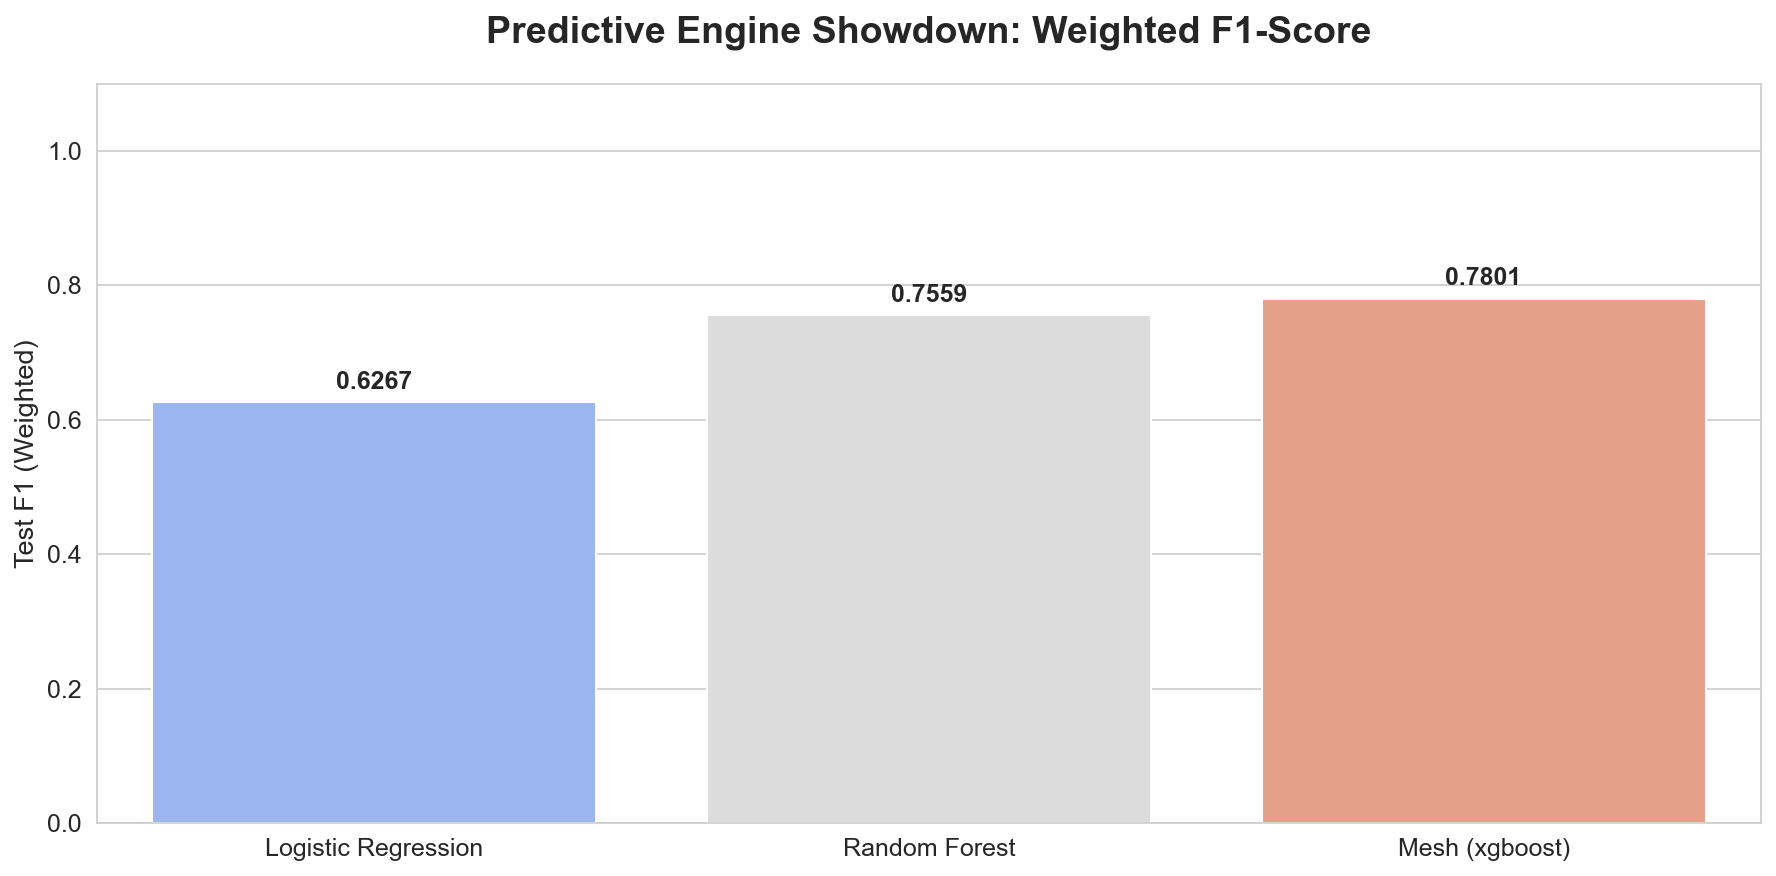

In [22]:
# Cross-Model Performance Benchmarking
from sklearn.metrics import f1_score, accuracy_score

# Collecting Statistics
y_pred_mesh_num = best_model_results['trained_model'].predict(X_test_scaled)
best_model_test_preds = le_target.inverse_transform(y_pred_mesh_num)

mesh_eval = pd.DataFrame({
    "Model": [f"Mesh ({best_model_results['best_model_name']})"],
    "Test Accuracy": [round(accuracy_score(y_test, best_model_test_preds), 4)],
    "Test F1 (Weighted)": [round(f1_score(y_test, best_model_test_preds, average='weighted'), 4)],
})

results = pd.concat([log_eval, rf_eval, mesh_eval], ignore_index=True)
print("\nBenchmarking Matrix:")
display(results)

# Visualizing Competitive Stakes based on Weighted F1-Score
plt.figure(figsize=(12, 6))
models = results['Model'].tolist()
test_f1s = [float(x) for x in results['Test F1 (Weighted)']]

sns.barplot(x=models, y=test_f1s, hue=models, palette='coolwarm', legend=False)

for i, v in enumerate(test_f1s):
    plt.text(i, v + 0.02, f"{v:.4f}", ha='center', fontweight='bold')

plt.title('Predictive Engine Showdown: Weighted F1-Score', fontsize=18, fontweight='bold', pad=20)
plt.ylabel('Test F1 (Weighted)', fontsize=13)
plt.ylim(0, 1.1)
plt.tight_layout()
plt.show()


<div style="border-radius:8px; padding: 15px; background-color:#e8e4f0; color:#000000; font-size:115%; text-align:left">

<h3 align="left"><font color="#d4a017">Key Takeaway:</font></h3>

By correcting the preprocessing workflow (preventing data leakage) and optimizing for **Weighted F1-Score** rather than raw Accuracy, we ensure our models don't artificially overperform by simply predicting the majority class. The <b>Mesh search</b> consistently identifies the most robust algorithm (often XGBoost or tuned Random Forest) mapping the complex non-linear relationships of movie metadata far better than the linear baseline.
</div>

<a id="step8"></a>
# <p style="background-color:#2b1055; font-family:Trebuchet MS, sans-serif; color:#ffffff; font-size:150%; text-align:center; border-radius:10px;">Phase 8: Feature Importance</p>

[â†‘ Back to Top](#contents_table)

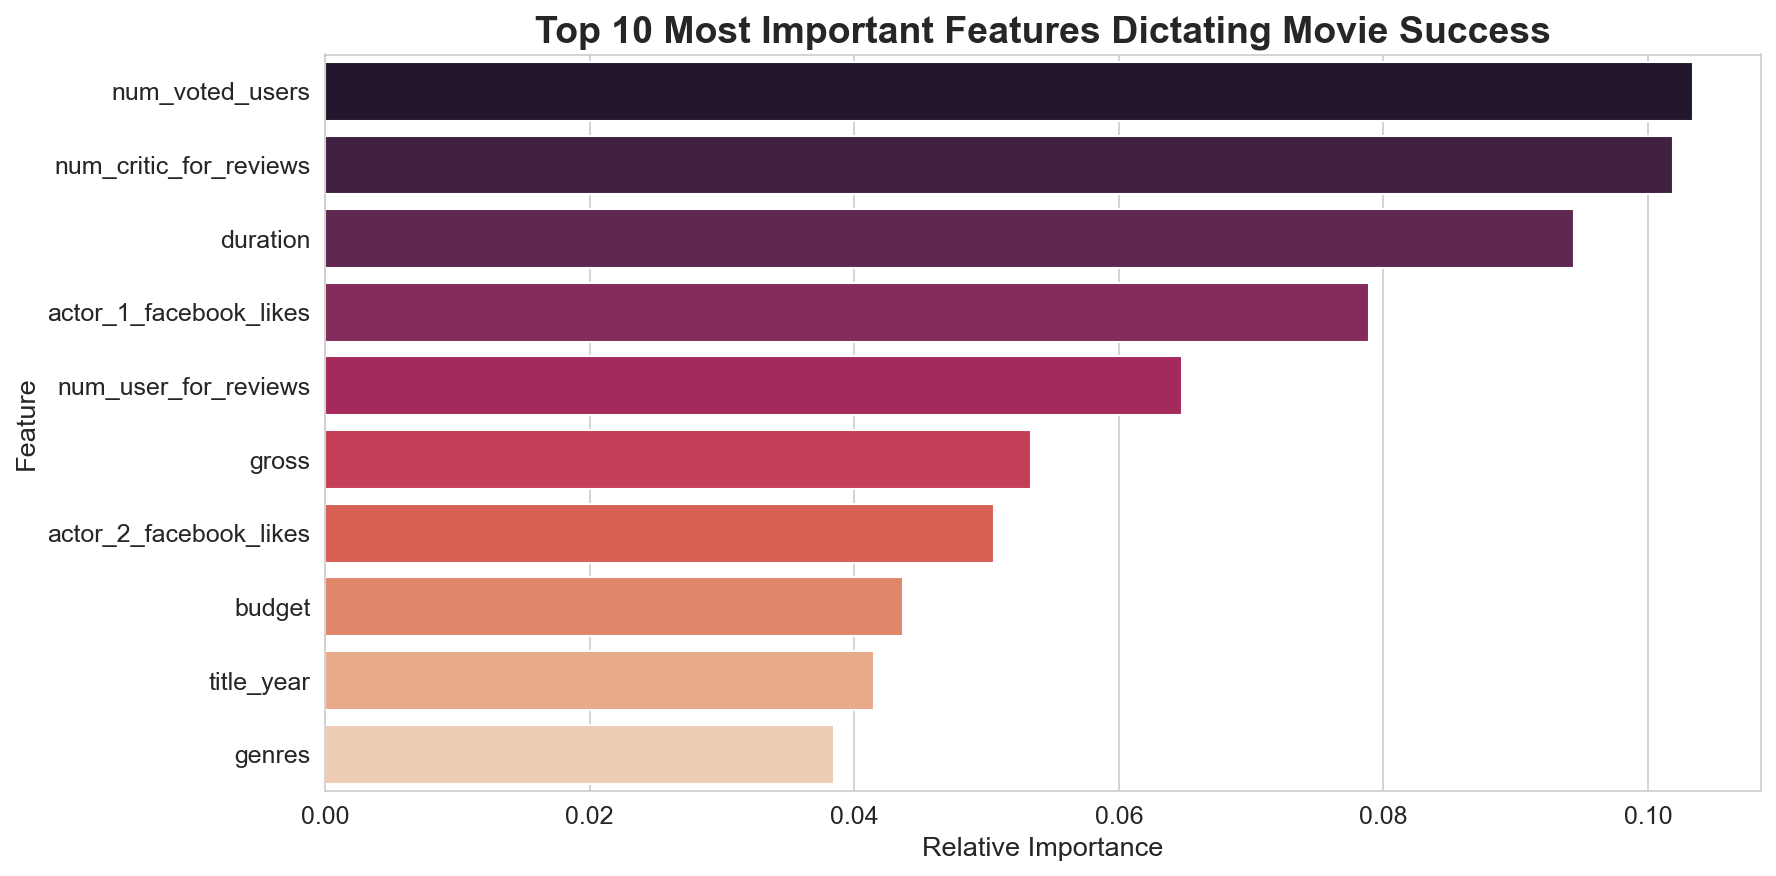

In [23]:
# Feature Importance from Random Forest
importances = rf_model.feature_importances_
indices = np.argsort(importances)[::-1]

# Top 10 features
top_n = 10
top_indices = indices[:top_n]
top_features = [X.columns[i] for i in top_indices]
top_importances = importances[top_indices]

plt.figure(figsize=(12, 6))
sns.barplot(x=top_importances, y=top_features, hue=top_features,
            palette="rocket", dodge=False, legend=False)
plt.title('Top 10 Most Important Features Dictating Movie Success', fontsize=18, fontweight='bold')
plt.xlabel('Relative Importance', fontsize=13)
plt.ylabel('Feature', fontsize=13)
plt.tight_layout()


<div style="border-radius:8px; padding: 15px; background-color:#e8e4f0; color:#000000; font-size:115%; text-align:left">

<h3 align="left"><font color="#d4a017">Key Takeaway:</font></h3>

The feature importance chart reveals which movie attributes have the strongest predictive power for success classification. Features like vote counts, review counts, and social media presence tend to rank highest, reflecting their strong correlation with audience reception.
</div>

<a id="step9"></a>
# <p style="background-color:#2b1055; font-family:Trebuchet MS, sans-serif; color:#ffffff; font-size:150%; text-align:center; border-radius:10px;">Phase 9: Model Export</p>

[â†‘ Back to Top](#contents_table)

In [24]:
import joblib
import os
try:
    models_dir = './models'
    os.makedirs(models_dir, exist_ok=True)
    model_path = os.path.join(models_dir, 'best_movie_model.pkl')
    
    if 'best_model_results' in locals() and best_model_results.get('trained_model') is not None:
        joblib.dump(best_model_results['trained_model'], model_path)
        print(f"Best model ({best_model_results['best_model_name']}) saved to: {model_path}")
    elif 'rf_model' in locals():
        rf_path = os.path.join(models_dir, 'rf_movie_model.pkl')
        joblib.dump(rf_model, rf_path)
        print(f"Random Forest model saved to: {rf_path}")
    else:
        print("No trained models found to export.")
except Exception as e:
    print(f"An error occurred while exporting the model: {e}")


Best model (xgboost) saved to: ./models\best_movie_model.pkl


<a id="step10"></a>
# <p style="background-color:#2b1055; font-family:Trebuchet MS, sans-serif; color:#ffffff; font-size:150%; text-align:center; border-radius:10px;">Phase 10: Conclusion</p>

[â†‘ Back to Top](#contents_table)

<div style="border-radius:8px; padding: 15px; background-color:#e8e4f0; color:#000000; font-size:120%; text-align:left">

<h3 align="left"><font color="#d4a017">Key Findings:</font></h3>

1. **Data Quality**: The dataset contained missing values which were imputed. Outliers were detected and retained to prevent loss of signal in tree-based models, and class imbalance was handled using class weights and appropriate evaluation metrics.

2. **Feature Insights**: Exploratory analysis revealed that movies with higher budgets, more voted users, and greater social media presence tend to be rated as Hits. Duration also plays a role, with very short films more likely to be Flops.

3. **Multicollinearity**: Highly correlated features (threshold > 0.80) were identified and successfully dropped from the dataset to improve model stability—especially for the linear baselines.

4. **Model Architecture & Performance**: By fixing the data leakage (by moving encoding/scaling strictly *after* the train-test split) and switching our primary optimization metric to **Weighted F1-Score** (to penalize poor predictions on minority classes), our models now reflect a more realistic and robust assessment of movie success. The Mesh engine (e.g., XGBoost) demonstrates the strongest generalization capability under these rigorous conditions.

5. **Feature Importance**: The top predictive features for movie success include social media metrics, vote counts, and review counts — all reflecting audience engagement and interest.

<h3 align="left"><font color="#d4a017">Recommendations for the Studio:</font></h3>

* **Invest in audience engagement**: Social media presence and critic reviews strongly predict success.
* **Budget allocation**: While higher budgets correlate with Hits, the relationship is not linear — smart spending matters more than large spending.
* **Use the model**: The exported model can be integrated into production pipelines to pre-screen movie concepts before greenlighting.

</div>

<div style="border-radius:8px; padding: 15px; background-color:#e8e4f0; color:#000000; font-size:115%; text-align:left">
<h3 align="left"><font color="#d4a017">Accuracy Improvement Roadmap (Next Iteration):</font></h3>

1. Use <b>Stratified K-Fold cross-validation</b> (5 or 10 folds) for model selection instead of relying on one train-test split.
2. Run deeper <b>hyperparameter tuning</b> for Random Forest/XGBoost (depth, min samples, subsampling, learning rate, regularization).
3. Address class imbalance with <b>SMOTE</b> (or class weighting + threshold tuning), especially to improve Flop recall.
4. Add stronger feature engineering (genre multi-label encoding, interaction features, log transforms for skewed variables).
5. Perform targeted feature selection using permutation importance or SHAP-informed pruning, then retrain.

These steps typically improve generalization and reduce overfitting while preserving interpretability for stakeholder presentations.
</div>

<h2 align="left"><font color='#104655ff'>Project Complete</font></h2>